In [1]:
from itertools import product
import psutil
from functools import partial
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
from qiskit_addon_sqd.counts import counts_to_arrays, bit_array_to_arrays
from tqdm.notebook import tqdm
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
import os
import matplotlib.pyplot as plt
from glob import glob
import seaborn as sns 
from tqdm.notebook import tqdm
from matplotlib import font_manager
import scipy.stats as stats
from shutil import move
font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 12})




# GMJ plot ideas
- Deviation from standard LUCJ (CCSD t1/t2 amps)
- Deviation of all initializations from HCI? (Maybe useless for this case; see point 1)
- Something to highlight SQDs "robustness" regarding initialization
    - Deviation from standard LUCJ (CCSD t1/t2 amps) but use barplot and explicitly highlight the GDB cases larger than 20 orbitals (see Kevin Sung where they mention initializations beyond 30 orbitals)
    - Boxplot deviations where the y-axis is deviations, x-axis is the basis set and the hue is the injection type
- Number of correct Hamming strings (ON vectors) *before* SQD

In [2]:
UofT_palette = [ "#1E3765",
                 "#007FA3", 
                 "#6D247A", 
                 "#DC4633",
                 "#6FC7EA",
                 "#00A189",
                 "#AB1368",
                 "#0D534D",
                 "#F1C500",
                 "#8DBF2E"
               ]

palette = sns.color_palette(UofT_palette)

In [3]:
energyDF=pd.read_csv("../../../classical/energies.csv",index_col=0).rename(columns={"Name":"Molecule"})
moldf = pd.read_csv('molecules.csv')
activespacedf = pd.read_csv("active_spaces.csv")
moldf['ActiveSpace'] = moldf.apply(lambda r: f"({int(r['n_electrons'])}, {int(r['num_orbitals'])})", axis=1)
moldf.sort_values(by=['num_orbitals','n_electrons'],inplace=True)
dimdf = pd.read_excel("Dimensions.xlsx",index_col=0).rename(columns={"Name":"Molecule","Basis":"Basis Set","Injection":"Injected"})

statsdf = pd.read_excel("circuitdepth.xlsx",index_col=0).rename(columns={"Name":"Molecule","Injection":"Injected"})
noconfigrecovdf = pd.read_csv("Energies_NoRecovery_checkpoint.csv").rename(columns={"Name":"Molecule","Basis":"Basis Set","Injection":"Injected"})

In [4]:
joinstatdf = pd.merge(dimdf, statsdf)

cols = ['Molecule', 'L', 'Basis Set', 'Injected']

# Left merge with indicator=True to find rows in joinstatdf missing from noconfigrecovdf
diff_df = pd.merge(
    joinstatdf[cols],
    noconfigrecovdf[cols],
    on=cols,
    how='left',
    indicator=True
)

# Define missing_rows from diff_df where the indicator shows 'left_only'
missing_rows = diff_df[diff_df['_merge'] == 'left_only'][cols]

# Filter joinstatdf for matching rows
matching_rows = joinstatdf[
    joinstatdf.set_index(cols).index.isin(missing_rows.set_index(cols).index)
]

In [5]:
matching_rows.shape

(45, 16)

In [6]:
statsmelt = joinstatdf.melt(id_vars=['Molecule','Basis Set','Injected','L'],value_vars=['Circuit Depth','Two-Qubit Depth','Two-Qubit Count'])

In [7]:
statsmelt

,Molecule,Basis Set,Injected,L,variable,value
0,(Z)-1-fluoroprop-1-ene,STO-3G,CCSD,1,Circuit Depth,635
1,(Z)-1-fluoroprop-1-ene,STO-3G,ML,1,Circuit Depth,632
2,(Z)-1-fluoroprop-1-ene,STO-3G,ML_exact,1,Circuit Depth,633
3,(Z)-1-fluoroprop-1-ene,STO-3G,MP2,1,Circuit Depth,635
4,(Z)-1-fluoroprop-1-ene,STO-3G,random,1,Circuit Depth,635
...,...,...,...,...,...,...
3235,water,cc-pVDZ,ML,5,Two-Qubit Count,644
3236,water,cc-pVDZ,ML_exact,5,Two-Qubit Count,652
3237,water,cc-pVDZ,MP2,5,Two-Qubit Count,498
3238,water,cc-pVDZ,random,5,Two-Qubit Count,652


/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_6719/39829178.py:1: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(


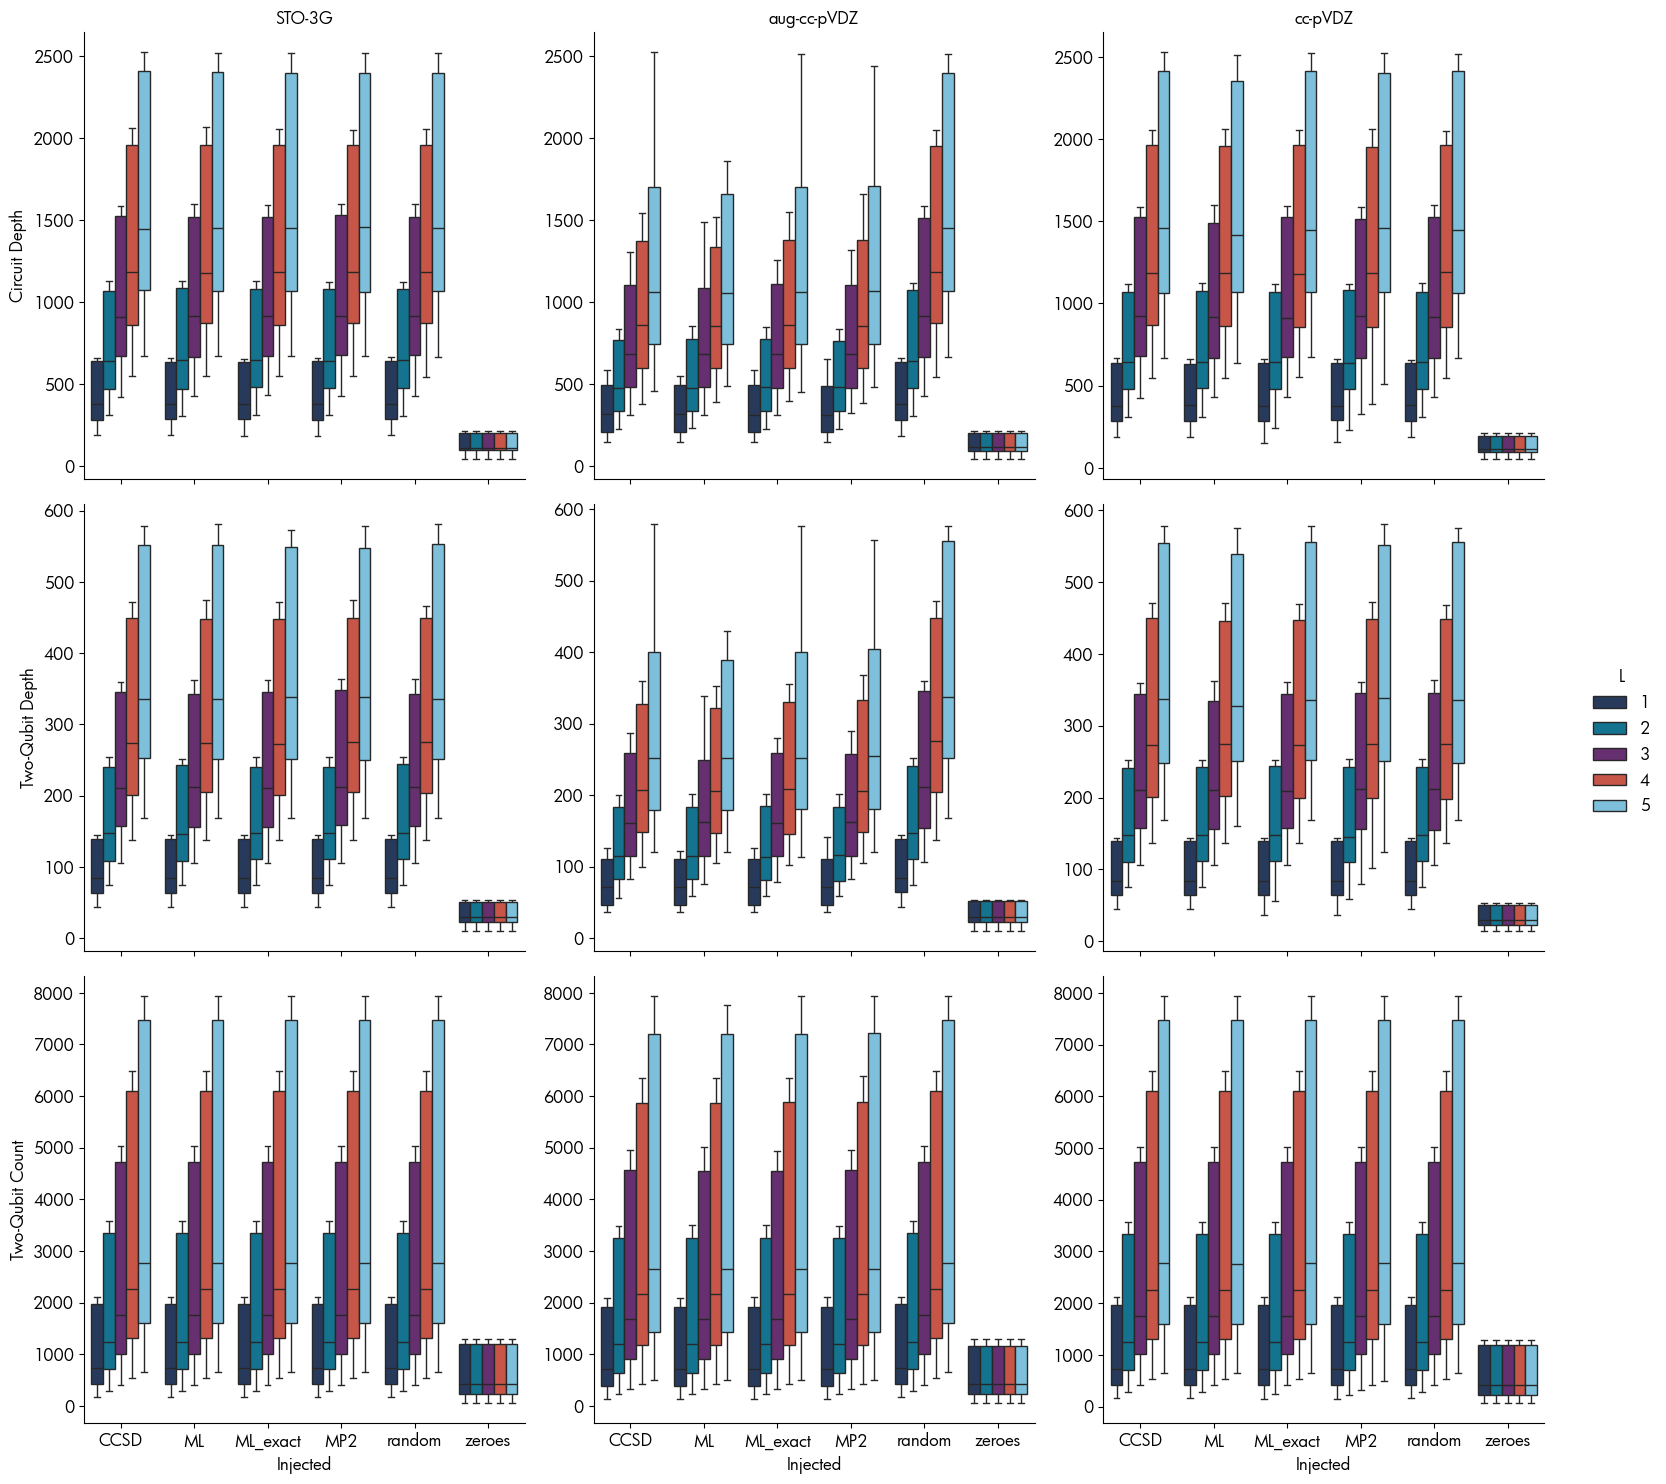

In [8]:
g = sns.catplot(
    statsmelt,
    x='Injected',
    y='value',
    hue='L',
    col='Basis Set',
    row='variable',
    kind='box',
    margin_titles=True,
    sharey=False,
    palette=palette
)

# 1. Clean up column titles to show ONLY the column name
g.set_titles(col_template="{col_name}", row_template="")

# 2. Label the row variable on the left y-axis for the leftmost plots
for ax, row_val in zip(g.axes[:, 0], statsmelt['variable'].unique()):
    ax.set_ylabel(row_val)

# 3. Move the legend outside to the right center
sns.move_legend(
    g, 
    loc="center left", 
    bbox_to_anchor=(1.01, 0.5), 
    frameon=False
)

plt.tight_layout()
plt.savefig("./GMJ_figures/DepthStatistics.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
energyDF

,Method,Energy,Molecule,Basis Set
0,HF,-74.960552,water,STO-3G
1,CASCI,-75.009479,water,STO-3G
2,SCI,-75.009478,water,STO-3G
0,HF,-55.454318,ammonia,STO-3G
1,CASCI,-55.519929,ammonia,STO-3G
...,...,...,...,...
31,DMRG-CASCI,-192.001410,prop-2-en-1-ol,cc-pVDZ
32,DMRG-CASCI,-189.749396,prop-2-en-1-ol,STO-3G
33,DMRG-CASCI,-215.950558,(Z)-1-fluoroprop-1-ene,aug-cc-pVDZ
34,DMRG-CASCI,-216.001106,(Z)-1-fluoroprop-1-ene,cc-pVDZ


In [10]:
import re

def process_list(data_list):
    """
    Processes a list of strings to perform the following operations:
    1.  Strips trailing newline characters.
    2.  Parses the 'LUCJ' string into three separate elements.
    3.  Converts the final element from a string to a float.
    """
    processed_list = []
    for item in data_list:
        item = item.strip()

        if "LUCJ" in item:
            # Use a regular expression to extract the components
            match = re.search(r'(LUCJ)\(L=(.*?)\)/(.*)', item)
            if match:
                processed_list.extend(match.groups())
            else:
                processed_list.append(item)
        else:
            processed_list.append(item)
    
    # Convert the last element to a float
    # We use a try-except block in case the last element is not a number
    try:
        processed_list[-1] = float(processed_list[-1])
    except (ValueError, IndexError):
        pass # The last element is not a float, so we ignore it

    return processed_list

In [11]:
postprocessed = []
new = []

for i in tqdm(glob("./energies/*txt"), desc='Running'):
    if 'StateVector' not in i:
        with open(i, 'r') as f:
            lines = f.readlines()
        
        # Filter out empty lines and non-energy metadata lines like 'Subspace Dimension'
        lines = [
            line for line in lines 
            if line.strip() and not line.strip().startswith("Subspace Dimension")
        ]
        
        processed = process_list(lines)
        
        # Clean energy string if needed
        if isinstance(processed[-1], str):
            # Strip 'Energy:', brackets, and whitespace
            clean_energy = (
                processed[-1]
                .replace("Energy:", "")
                .strip(" []\t\n")
            )
            processed[-1] = float(clean_energy)
            
        # Build dataframe with clean types
        cols = ["Basis Set", "Molecule", "Method", "L", "Injected", "Energy"]
        moldict = pd.DataFrame([dict(zip(cols, processed))]).astype({"L": int, "Energy": float})
        
        postprocessed.append(moldict)
        new.append(i)

Running:   0%|          | 0/1260 [00:00<?, ?it/s]

In [12]:
LUCJDF=pd.concat(postprocessed).reset_index().drop(columns=['index']).astype({"L":int,"Energy":float})
LUCJDF['Method'] = LUCJDF.apply(
    lambda row: f"LUCJ(L={row['L']}/{row['Injected']})", 
    axis=1
)

In [13]:
# LUCJDF[LUCJDF['Energy']<-1e3].to_excel("repostprocess.xlsx")

In [14]:
n_atoms_dict = {
    'water': 3,
    'methane': 5,
    'ammonia': 4,
    'ethane': 8,
    'methanol': 6,
    'ethylene': 6,
    'formaldehyde': 4,
    "prop-2-en-1-ol":10,
    "but-1-yne":10,
    "fluoroform":5,
    "buta-1,3-diene":10,
    "(Z)-1-fluoroprop-1-ene":9
}

LUCJDF['n_atoms'] = LUCJDF['Molecule'].map(n_atoms_dict)

In [15]:
# uniqueBasis = LUCJDF['Basis Set'].unique()
uniqueBasis = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ']
uniqueMol = sorted(LUCJDF['Molecule'].unique(), key=lambda user: n_atoms_dict.get(user, 0))
# uniqueInj = LUCJDF['Injected'].unique()
uniqueInj = ['zeroes', 'random', 'MP2', 'ML', 'ML_exact', 'CCSD']
uniqueLayers = np.sort(LUCJDF['L'].unique())
uniqueMethods = np.hstack([LUCJDF['Method'].sort_values().unique(),energyDF['Method'].unique()])

In [16]:
# Filter LUCJDF to only include exact matching rows from matching_rows
exact_matches = LUCJDF.merge(matching_rows, how="inner")

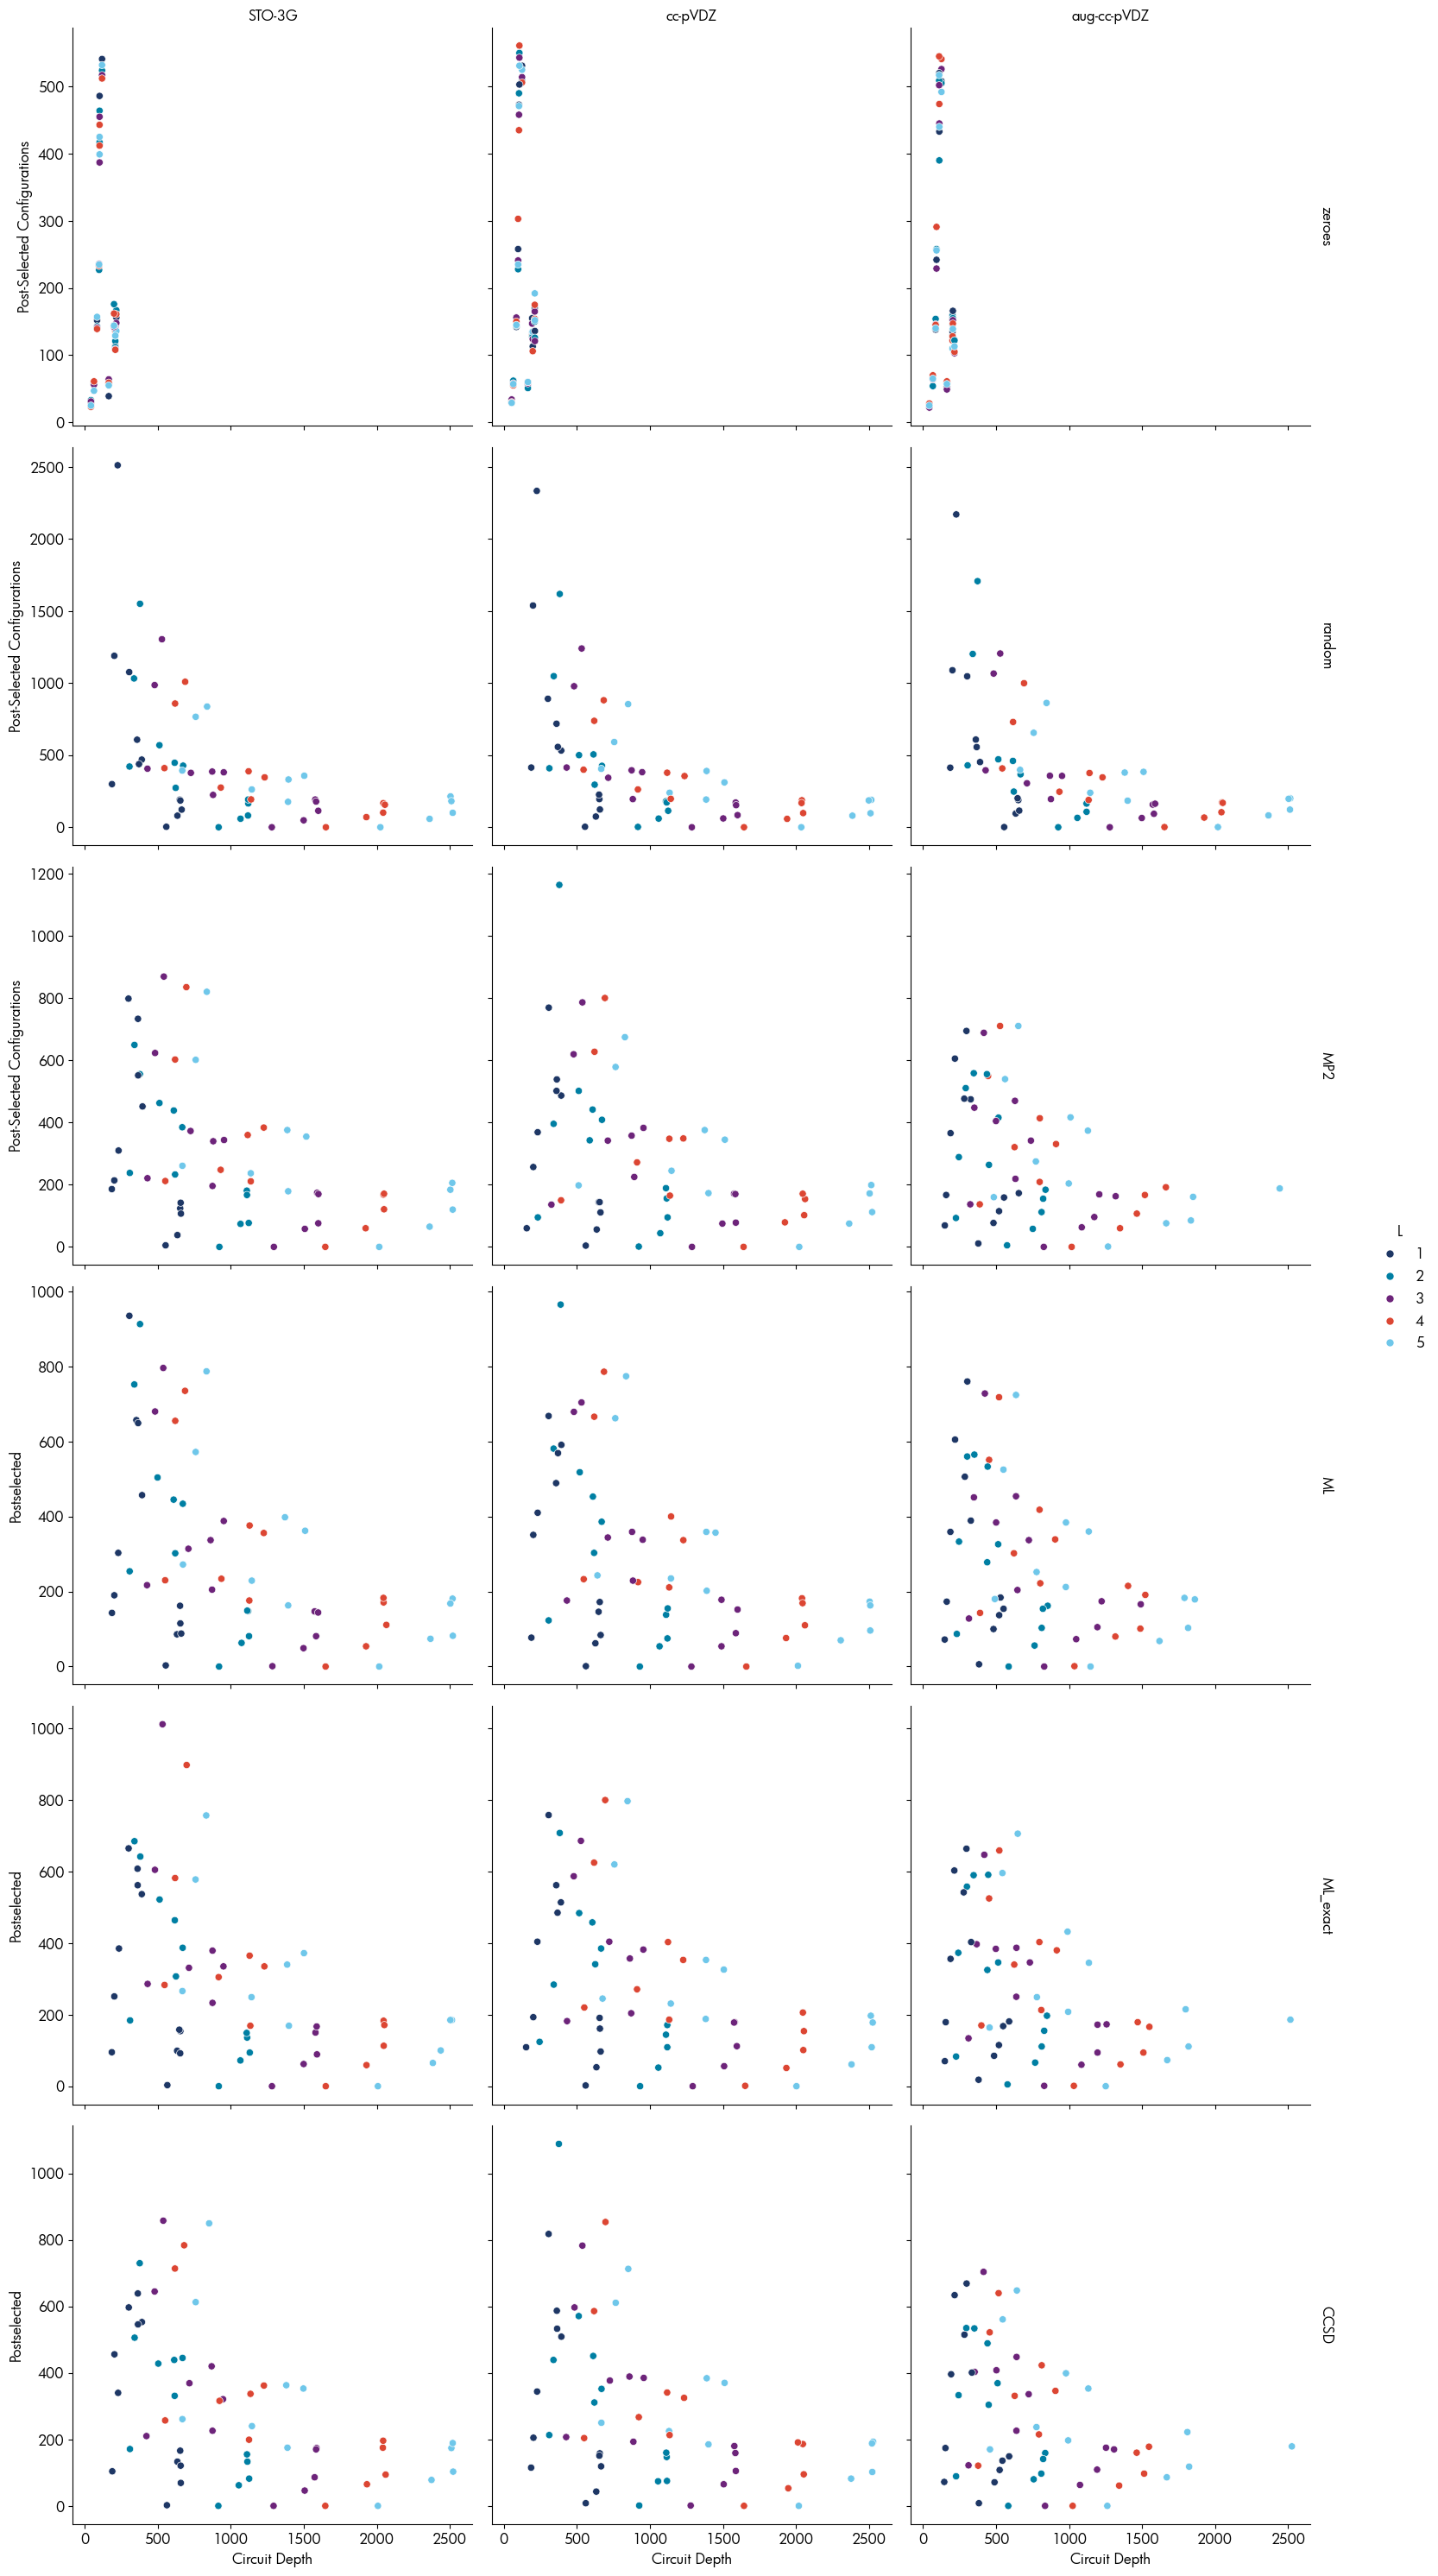

In [17]:
g = sns.relplot(
    joinstatdf,
    y='Postselected',
    x='Circuit Depth',
    row='Injected',
    col='Basis Set',
    hue='L',
    kind='scatter',
    col_order=uniqueBasis,
    row_order=uniqueInj,
    palette=palette[:uniqueLayers[-1]], # Prevent palette warning
    facet_kws={'sharey': 'row', 'margin_titles': True} # Pass grid arguments here
)

# 1. Clean up column titles to show ONLY the column name
g.set_titles(col_template="{col_name}", row_template="{row_name}")

# 2. Label the row variable on the left y-axis for the leftmost plots
for ax, row_val in zip(g.axes[:, 0], statsmelt['variable'].unique()):

    ax.set_ylabel(r"Post-Selected Configurations")
# 3. Move the legend outside to the right center
sns.move_legend(
    g, 
    loc="center left", 
    bbox_to_anchor=(1.01, 0.5), 
    frameon=False
)

plt.tight_layout()
plt.savefig("./GMJ_figures/DepthvsPostselected.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
for basis, layer, mol in product(uniqueBasis, uniqueLayers, uniqueMol):
    mask = (
        (LUCJDF['Basis Set'] == basis) &
        (LUCJDF['L'] == layer) &
        (LUCJDF['Molecule'] == mol)
    )
    
    # If no data exists for this mask in LUCJDF, skip to next iteration
    if not mask.any():
        continue

    # Determine standard or mapping name for energyDF lookup
    lookup_mol = mol
    sci_sub = energyDF[(energyDF['Molecule'] == lookup_mol) & (energyDF['Basis Set'] == basis) & (energyDF['Method'] == 'SCI')]
    
    # If standard lookup fails, try converting via moldf
    if sci_sub.empty and 'moldf' in globals():
        mapped = moldf.loc[moldf['molecule'] == mol, 'xyz'] if 'xyz' in moldf.columns else moldf.loc[moldf['molecule'] == mol, 'mol_filename']
        if not mapped.empty:
            lookup_mol = mapped.values[0].replace('.xyz', '')

    # Helper function to safely extract scalar energy or np.nan if absent
    def get_energy(method_name):
        sub = energyDF[(energyDF['Molecule'] == lookup_mol) & 
                       (energyDF['Basis Set'] == basis) & 
                       (energyDF['Method'] == method_name)]
        return sub['Energy'].values[0] if not sub.empty else np.nan

    sci_energy = get_energy('SCI')
    hf_energy = get_energy('HF')
    casci_energy = get_energy('CASCI')
    dmrg_energy = get_energy('DMRG-CASCI')

    # Assign values safely
    # if not np.isnan(sci_energy):
    #     LUCJDF.loc[mask, 'Deviation'] = (LUCJDF.loc[mask, "Energy"] - dmrg_energy) * 1e3
    LUCJDF.loc[mask, 'Energy (HCI)'] = sci_energy

    LUCJDF.loc[mask, 'Energy (HF)'] = hf_energy
    LUCJDF.loc[mask, 'Energy (CASCI)'] = casci_energy
    LUCJDF.loc[mask, 'Energy (DMRG-CASCI)'] = dmrg_energy
LUCJDF.sort_values(by=['Basis Set','L','n_atoms','Injected'],inplace=True)

In [19]:
compareCRdf = pd.merge(LUCJDF,noconfigrecovdf)

In [20]:
LUCJDF

,Basis Set,Molecule,Method,L,Injected,Energy,n_atoms,Energy (HCI),Energy (HF),Energy (CASCI),Energy (DMRG-CASCI)
503,STO-3G,water,LUCJ(L=1/CCSD),1,CCSD,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479
258,STO-3G,water,LUCJ(L=1/ML),1,ML,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479
729,STO-3G,water,LUCJ(L=1/ML_exact),1,ML_exact,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479
515,STO-3G,water,LUCJ(L=1/MP2),1,MP2,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479
484,STO-3G,water,LUCJ(L=1/random),1,random,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479
...,...,...,...,...,...,...,...,...,...,...,...
851,cc-pVDZ,"buta-1,3-diene",LUCJ(L=5/random),5,random,-154.934639,10,-155.015451,-154.933920,NaN,-155.019314
1013,cc-pVDZ,prop-2-en-1-ol,LUCJ(L=5/random),5,random,-191.937005,10,-191.997481,-191.936495,NaN,-192.001410
62,cc-pVDZ,but-1-yne,LUCJ(L=5/zeroes),5,zeroes,-154.978498,10,-155.000448,-154.911388,NaN,-155.006670
853,cc-pVDZ,"buta-1,3-diene",LUCJ(L=5/zeroes),5,zeroes,-154.989076,10,-155.015451,-154.933920,NaN,-155.019314


In [21]:
flatteneddev = []


In [22]:
for energies in ["Energy","Energy (HF)","Energy (CASCI)","Energy (HCI)","Energy (DMRG-CASCI)"]:
    if "(" not in energies:
        
        LUCJDF["Deviation (LUCJ)"] = (LUCJDF[energies] - LUCJDF["Energy"]) * 1e3
    else:
        # Other reference energies -> Deviation (HF), Deviation (CASCI), etc.
        dev_col_name = energies.replace("Energy", "Deviation")
        LUCJDF[dev_col_name] = (LUCJDF[energies] - LUCJDF["Energy"]) * 1e3

In [23]:
(compareCRdf['Energy (DMRG-CASCI)']<=compareCRdf['Energy (HCI)']).describe()

count     1035
unique       2
top       True
freq       885
dtype: object

In [24]:
for energies in ["Energy",'Energy_NoRecovery',"Energy (HF)","Energy (CASCI)","Energy (HCI)","Energy (DMRG-CASCI)"]:
    if "(" not in energies and '_' not in energies:
        
        compareCRdf["Deviation (LUCJ)"] = (compareCRdf[energies] - compareCRdf["Energy"]) * 1e3
    else:
        # Other reference energies -> Deviation (HF), Deviation (CASCI), etc.
        dev_col_name = energies.replace("Energy", "Deviation")
        compareCRdf[dev_col_name] = (compareCRdf[energies] - compareCRdf["Energy"]) * 1e3

In [52]:
compareCRdf

,Basis Set,Molecule,Method,L,Injected,Energy,n_atoms,Energy (HCI),Energy (HF),Energy (CASCI),Energy (DMRG-CASCI),Energy_NoRecovery,SubspaceDim_NoRecovery,Deviation (LUCJ),Deviation_NoRecovery,Deviation (HF),Deviation (CASCI),Deviation (HCI),Deviation (DMRG-CASCI)
0,STO-3G,water,LUCJ(L=1/CCSD),1,CCSD,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479,-75.009479,441,0.0,-0.000005,48.926578,-0.000136,0.000292,-0.000136
1,STO-3G,water,LUCJ(L=1/ML),1,ML,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479,-75.009479,441,0.0,-0.000005,48.926578,-0.000136,0.000292,-0.000136
2,STO-3G,water,LUCJ(L=1/ML_exact),1,ML_exact,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479,-75.009479,441,0.0,-0.000005,48.926578,-0.000136,0.000292,-0.000136
3,STO-3G,water,LUCJ(L=1/MP2),1,MP2,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479,-75.009479,441,0.0,-0.000005,48.926578,-0.000136,0.000292,-0.000136
4,STO-3G,water,LUCJ(L=1/random),1,random,-75.009479,3,-75.009478,-74.960552,-75.009479,-75.009479,-75.009479,441,0.0,-0.000005,48.926578,-0.000136,0.000292,-0.000136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1030,cc-pVDZ,"buta-1,3-diene",LUCJ(L=5/random),5,random,-154.934639,10,-155.015451,-154.933920,NaN,-155.019314,-154.933920,139129,0.0,0.718796,0.718796,NaN,-80.811751,-84.674787
1031,cc-pVDZ,prop-2-en-1-ol,LUCJ(L=5/random),5,random,-191.937005,10,-191.997481,-191.936495,NaN,-192.001410,-191.936495,38025,0.0,0.509448,0.509446,NaN,-60.476047,-64.405491
1032,cc-pVDZ,but-1-yne,LUCJ(L=5/zeroes),5,zeroes,-154.978498,10,-155.000448,-154.911388,NaN,-155.006670,-154.923330,137641,0.0,55.168217,67.109636,NaN,-21.950454,-28.172054
1033,cc-pVDZ,"buta-1,3-diene",LUCJ(L=5/zeroes),5,zeroes,-154.989076,10,-155.015451,-154.933920,NaN,-155.019314,-154.937185,59536,0.0,51.891137,55.155516,NaN,-26.375031,-30.238067


In [61]:
mean_absolute_error(compareCRdf['Energy_NoRecovery'],compareCRdf['Energy'])*1e3

18.612061692097

In [57]:
1080 - 1035

45

In [37]:
MAEsCR=[]
for basis, layer, injected in product(uniqueBasis, uniqueLayers, uniqueInj):
    mask = (
        (compareCRdf['Basis Set'] == basis)
        & (compareCRdf['L'] == layer)
        & (compareCRdf['Injected'] == injected)
    )

    # Subset the masked data for this iteration
    sub_df = compareCRdf.loc[mask]

    # for energies in [
    #     'Energy',
    #     'Energy_NoRecovery',
    #     # 'Energy (HF)',
    #     # 'Energy (CASCI)',
    #     # 'Energy (HCI)',
    #     # 'Energy (DMRG-CASCI)',
    # ]:
    #     # Drop NaNs from target energy column to align with valid ground truth rows
    valid_data = sub_df[['Energy', 'Energy_NoRecovery']].dropna()

    if valid_data.empty:
        continue

    mae = (
        mean_absolute_error(valid_data['Energy_NoRecovery'], valid_data['Energy'])
        * 1e3
    )
    MAEsCR.append((basis, layer, injected, energies, mae))

In [38]:
MAEsCR

[('STO-3G', np.int64(1), 'zeroes', 'Energy_NoRecovery', 76.73073222108624),
 ('STO-3G', np.int64(1), 'random', 'Energy_NoRecovery', 40.55851203723174),
 ('STO-3G', np.int64(1), 'MP2', 'Energy_NoRecovery', 35.121872370279895),
 ('STO-3G', np.int64(1), 'ML', 'Energy_NoRecovery', 35.56991722457129),
 ('STO-3G', np.int64(1), 'ML_exact', 'Energy_NoRecovery', 33.65837234190927),
 ('STO-3G', np.int64(1), 'CCSD', 'Energy_NoRecovery', 38.9721013346603),
 ('STO-3G', np.int64(2), 'zeroes', 'Energy_NoRecovery', 75.91582202964571),
 ('STO-3G', np.int64(2), 'random', 'Energy_NoRecovery', 43.537557032466495),
 ('STO-3G', np.int64(2), 'MP2', 'Energy_NoRecovery', 32.16087622142538),
 ('STO-3G', np.int64(2), 'ML', 'Energy_NoRecovery', 26.300307645730538),
 ('STO-3G', np.int64(2), 'ML_exact', 'Energy_NoRecovery', 23.49505604507388),
 ('STO-3G', np.int64(2), 'CCSD', 'Energy_NoRecovery', 26.539768926799535),
 ('STO-3G', np.int64(3), 'zeroes', 'Energy_NoRecovery', 79.5617750328077),
 ('STO-3G', np.int64(3),

In [27]:
mean_absolute_error(compareCRdf['Energy'],compareCRdf['Energy_NoRecovery'])*1e3

18.612061692097

In [28]:
# --- 1. DATA PREPARATION ---
CRmergedwactivespaces = pd.merge(
    compareCRdf, 
    moldf.rename(columns={"molecule": 'Molecule'})[['Molecule', 'ActiveSpace', 'num_orbitals', 'n_electrons']]
)

CRmeltedrefdevs = CRmergedwactivespaces.melt(
    id_vars=['Basis Set', 'Molecule', 'L', 'Injected', 'ActiveSpace', 'num_orbitals', 'n_electrons'],
    value_vars=["Deviation (HF)", "Deviation (CASCI)", "Deviation (DMRG-CASCI)", "Deviation (HCI)", 'Deviation_NoRecovery'],
    var_name='Method',
    value_name='Deviation'
)

# Fix: Handle 'Deviation_NoRecovery' cleanly alongside space-delimited string names
CRmeltedrefdevs['Method'] = CRmeltedrefdevs['Method'].map(
    lambda x: x.split()[1].strip('()') if ' ' in x else x.replace('Deviation_', '')
)

# Sort by orbitals first, then electrons, then extract unique ActiveSpace values in that exact order
CRsorted_spaces = (
    CRmeltedrefdevs
    .sort_values(by=['num_orbitals', 'n_electrons'])['ActiveSpace']
    .unique()
)

# Set ActiveSpace as a Categorical column so Seaborn uses the sorted order
CRmeltedrefdevs['ActiveSpace'] = pd.Categorical(
    CRmeltedrefdevs['ActiveSpace'], 
    categories=CRsorted_spaces, 
    ordered=True
)

# Sorting the final dataframe
CRmeltedrefdevs = CRmeltedrefdevs.sort_values(by=['Basis Set', 'L', 'Injected', 'num_orbitals', 'n_electrons'])

In [29]:
CRmeltedrefdevs

,Basis Set,Molecule,L,Injected,ActiveSpace,num_orbitals,n_electrons,Method,Deviation
0,STO-3G,water,1,CCSD,"(10, 7)",7,10,HF,48.926578
1035,STO-3G,water,1,CCSD,"(10, 7)",7,10,CASCI,-0.000136
2070,STO-3G,water,1,CCSD,"(10, 7)",7,10,DMRG-CASCI,-0.000136
3105,STO-3G,water,1,CCSD,"(10, 7)",7,10,HCI,0.000292
4140,STO-3G,water,1,CCSD,"(10, 7)",7,10,NoRecovery,-0.000005
...,...,...,...,...,...,...,...,...,...
1034,cc-pVDZ,prop-2-en-1-ol,5,zeroes,"(32, 26)",26,32,HF,30.319496
2069,cc-pVDZ,prop-2-en-1-ol,5,zeroes,"(32, 26)",26,32,CASCI,NaN
3104,cc-pVDZ,prop-2-en-1-ol,5,zeroes,"(32, 26)",26,32,DMRG-CASCI,-34.595441
4139,cc-pVDZ,prop-2-en-1-ol,5,zeroes,"(32, 26)",26,32,HCI,-30.665997


In [30]:
uniqueInj

['zeroes', 'random', 'MP2', 'ML', 'ML_exact', 'CCSD']

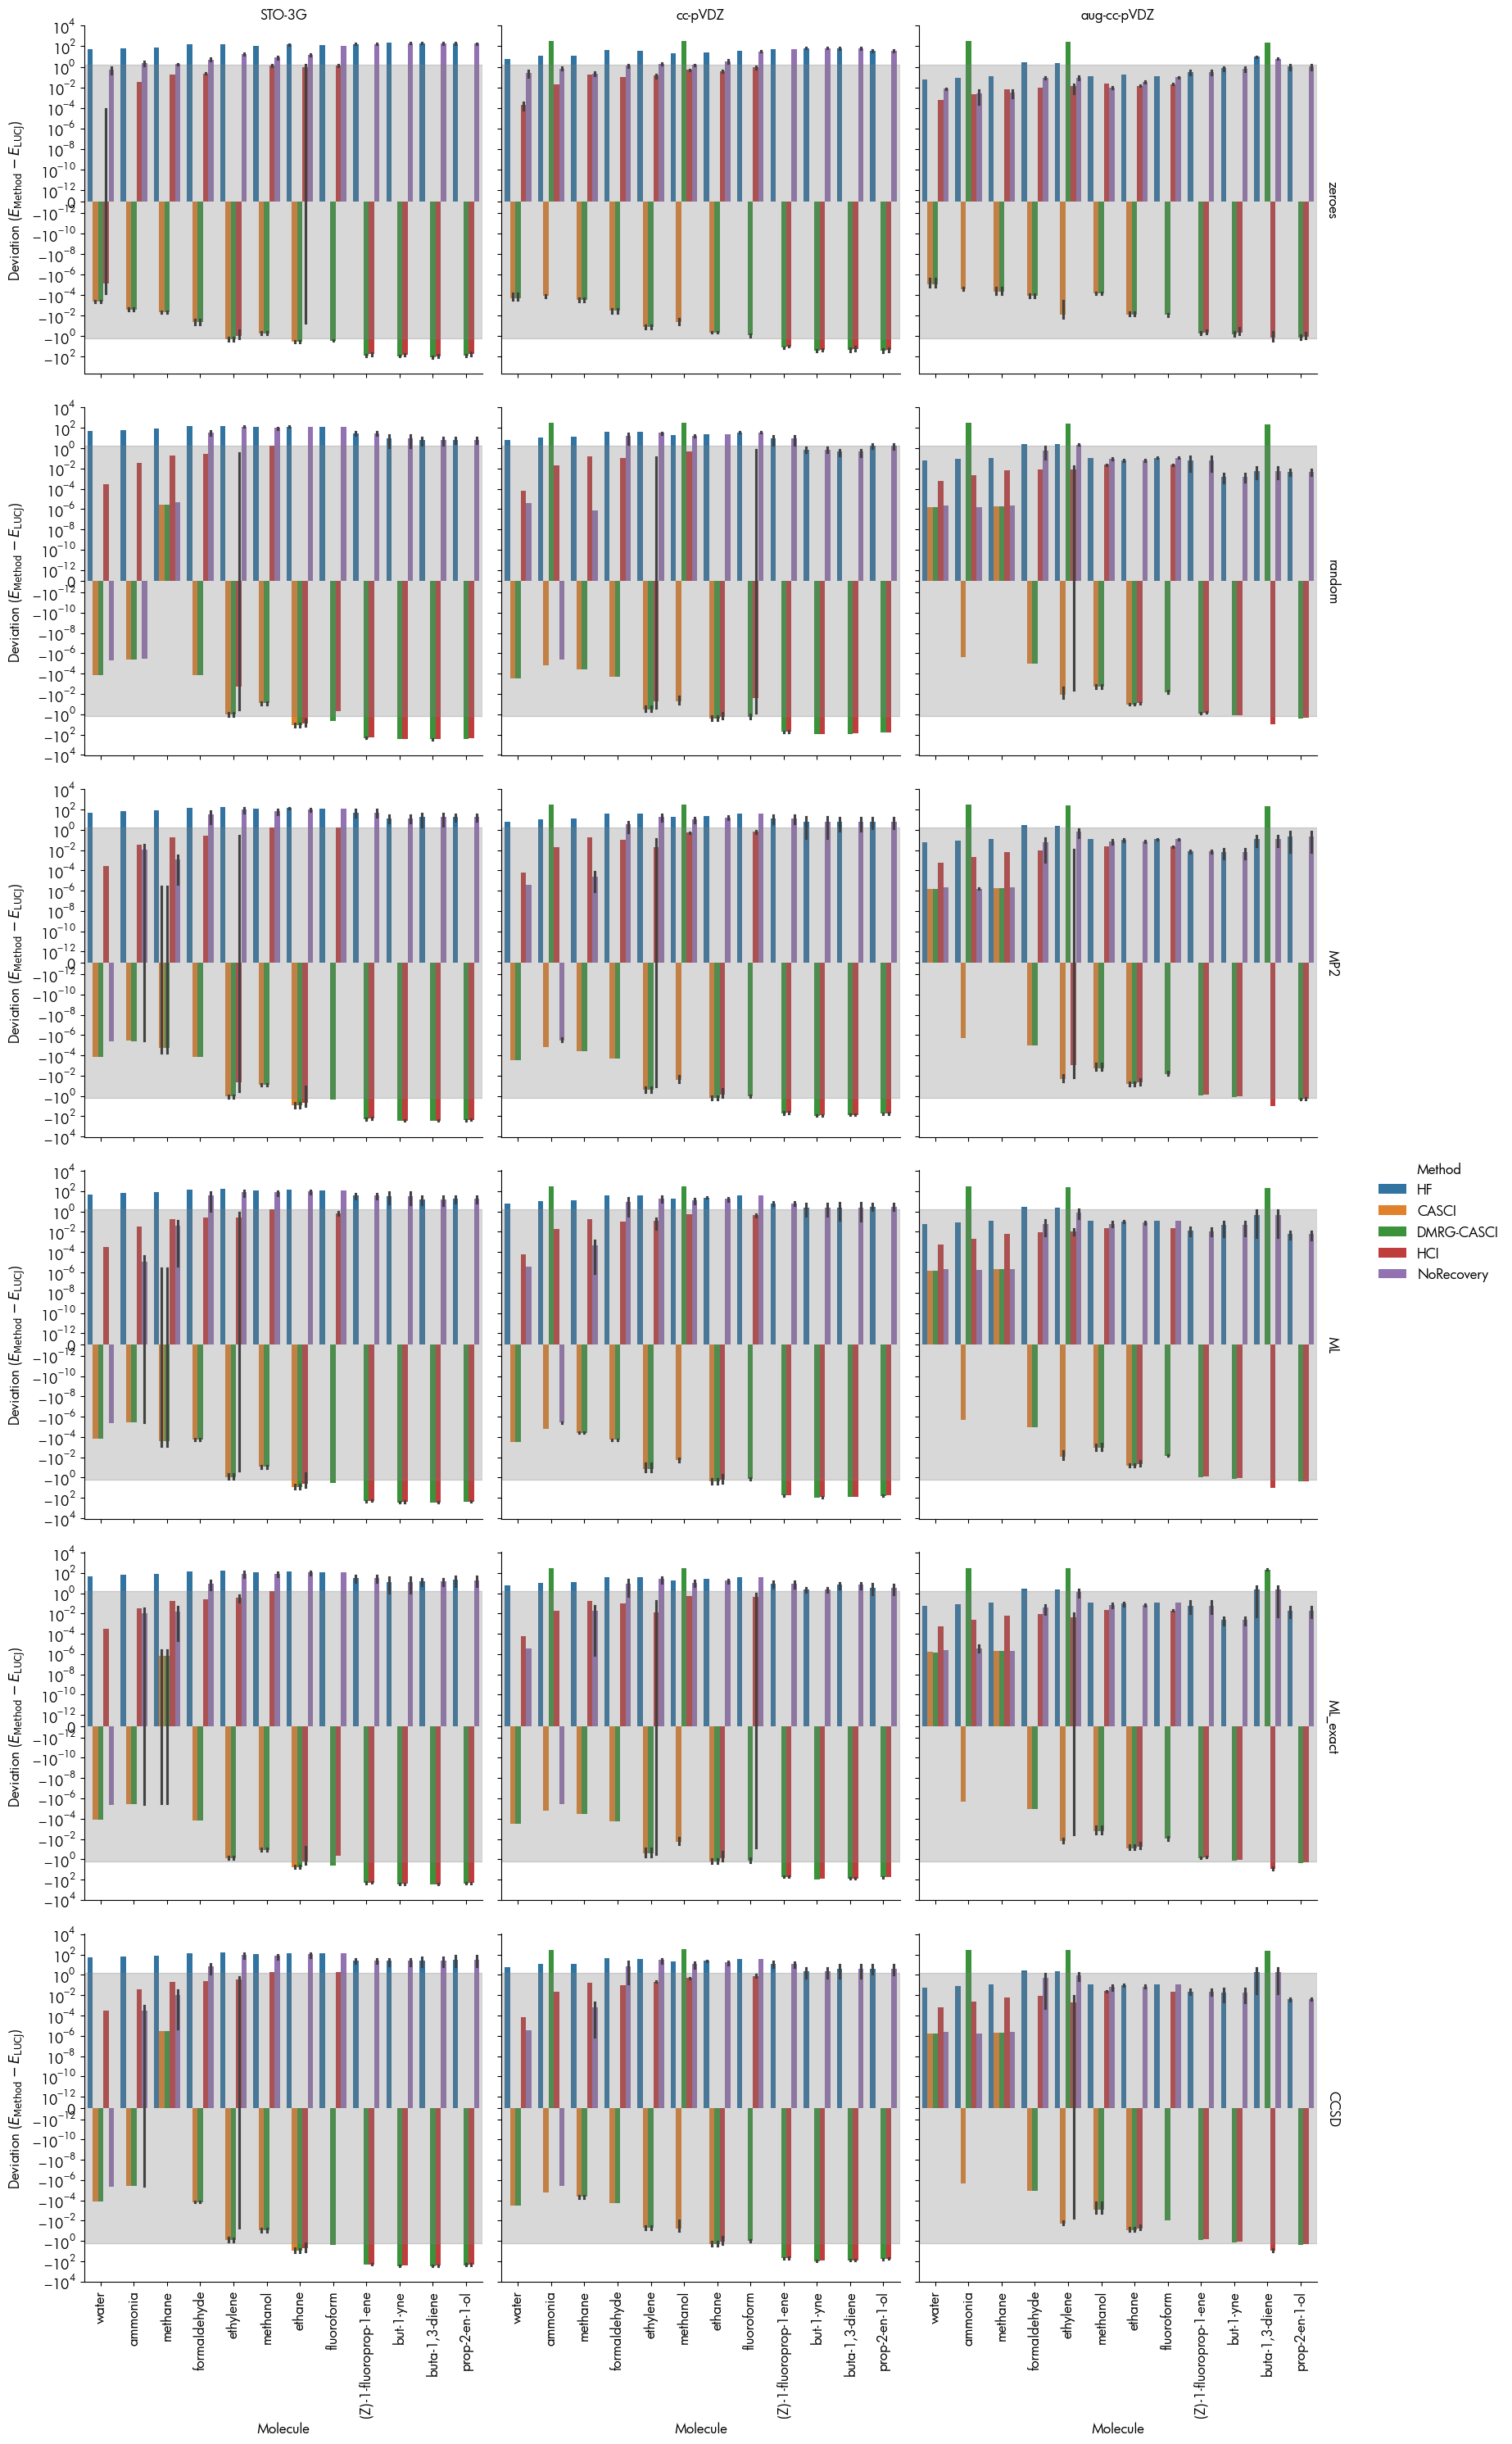

In [32]:
g = sns.catplot(CRmeltedrefdevs.sort_values(by=['num_orbitals','n_electrons','L']),
                col='Basis Set',
                y='Deviation',
                x='Molecule',
                row='Injected',
                hue='Method',
                kind='bar',
                col_order=uniqueBasis,
                row_order=uniqueInj,
                sharey='row',
                margin_titles=True
               )


g.set_titles(col_template="{col_name}", row_template="{row_name}")

# Apply symlog scale and accuracy band to all axes
for ax in g.axes.flat:
    ax.set_yscale("symlog",linthresh=1e-12)
    ax.axhspan(-1.6, 1.6, color="gray", alpha=0.3)
    ax.set_ylabel(r"Deviation ($E_{\mathrm{Method}} - E_{\mathrm{LUCJ}}$)")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

sns.move_legend(g, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout()
plt.savefig("./GMJ_figures/DeviationsfromLUCJ.png", dpi=300, bbox_inches='tight')
plt.show()

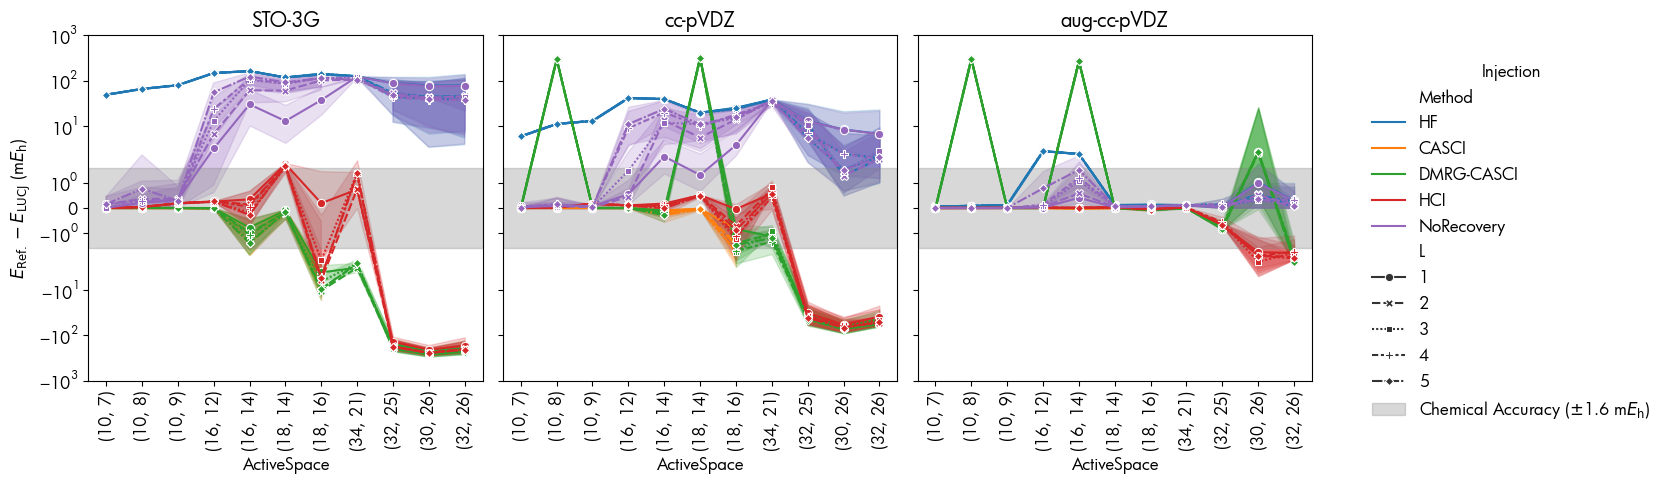

In [31]:
# --- 2. PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Loop through subplots using uniqueBasis
for ax, bs in zip(axes, uniqueBasis):
    # Filter for the specific basis set
    CRsubset = CRmeltedrefdevs[CRmeltedrefdevs['Basis Set'] == bs]
    
    # Plot on the specific subplot
    sns.lineplot(
        data=CRsubset,
        x='ActiveSpace',
        y='Deviation',
        hue='Method',
        style='L',
        legend=True,
        ax=ax,
        markers=True
    )
    
    ax.set_title(bs)
    ax.set_yscale("symlog")
    ax.axhspan(-1.6, 1.6, color="gray", alpha=0.3, label=r"Chemical Accuracy ($\pm$1.6 m$E_{\mathrm{h}}$)")
    ax.set_ylabel(r"$E_{\mathrm{Ref.}} - E_{\mathrm{LUCJ}}$ (m$E_{\mathrm{h}}$)")
    ax.set_ylim(-1e3, 1e3)
    
    # Rotate tick labels for each subplot
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Extract handles and labels from the last subplot
handles, labels = axes[-1].get_legend_handles_labels()

# Remove individual legends
for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

# Add the single shared legend
fig.legend(
    handles, labels, 
    title='Injection', 
    loc='center left', 
    bbox_to_anchor=(0.91, 0.5), 
    frameon=False
)

plt.tight_layout()
fig.subplots_adjust(right=0.88)  # Make room for external legend
# plt.savefig("./GMJ_figures/DeviationsVsActiveSpaces.png", dpi=300, bbox_inches='tight')
plt.show()

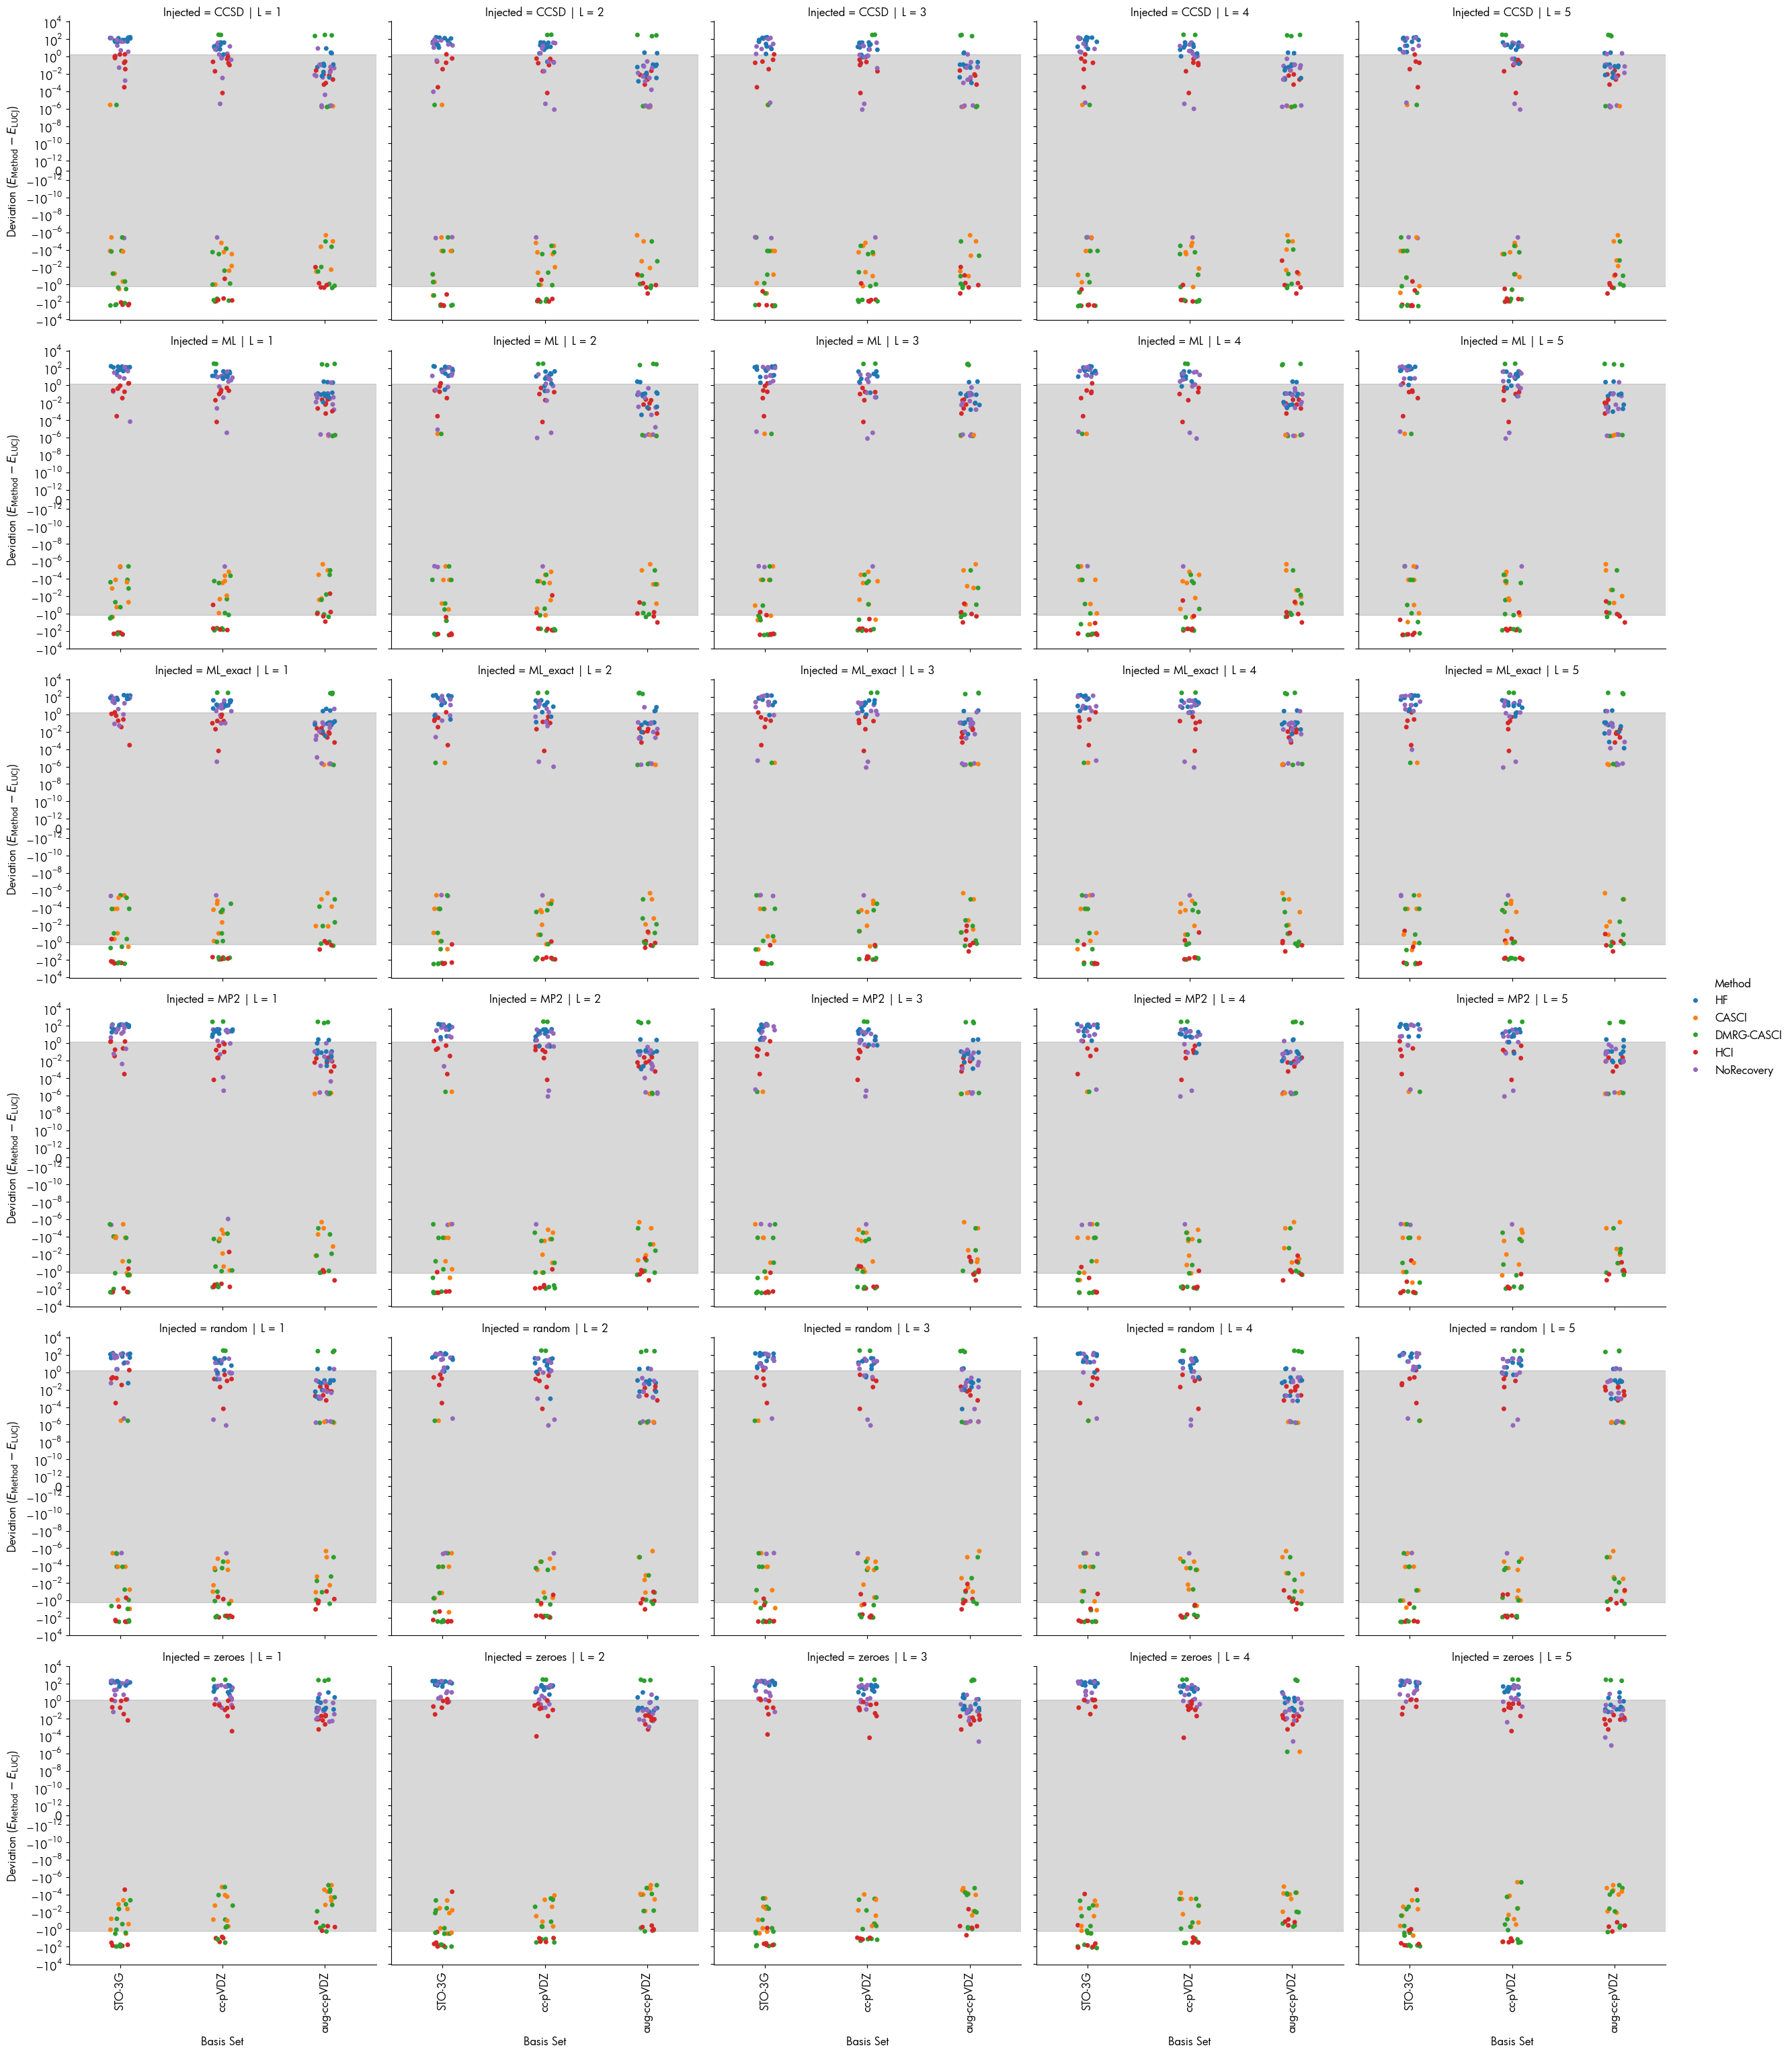

In [32]:
g = sns.catplot(CRmeltedrefdevs.sort_values(by=['num_orbitals','n_electrons','L']),x='Basis Set',y='Deviation',hue='Method',row='Injected',col='L',order=uniqueBasis)
# Apply symlog scale and accuracy band to all axes
for ax in g.axes.flat:
    ax.set_yscale("symlog",linthresh=1e-12)
    ax.axhspan(-1.6, 1.6, color="gray", alpha=0.3)
    ax.set_ylabel(r"Deviation ($E_{\mathrm{Method}} - E_{\mathrm{LUCJ}}$)")
    for label in ax.get_xticklabels():
        label.set_rotation(90)


In [33]:
# --- 1. DATA PREPARATION ---
mergedwactivespaces = pd.merge(
    LUCJDF, 
    moldf.rename(columns={"molecule": 'Molecule'})[['Molecule', 'ActiveSpace', 'num_orbitals', 'n_electrons']]
)

meltedrefdevs = mergedwactivespaces.melt(
    id_vars=['Basis Set', 'Molecule', 'L', 'Injected', 'ActiveSpace', 'num_orbitals', 'n_electrons'],
    value_vars=["Deviation (HF)", "Deviation (CASCI)", "Deviation (DMRG-CASCI)", "Deviation (HCI)"],
    var_name='Method',
    value_name='Deviation'
)
meltedrefdevs['Method'] = meltedrefdevs['Method'].map(lambda x: x.split()[1].strip('()'))

# Sort by orbitals first, then electrons, then extract unique ActiveSpace values in that exact order
sorted_spaces = (
    meltedrefdevs
    .sort_values(by=['num_orbitals', 'n_electrons'])['ActiveSpace']
    .unique()
)

# Set ActiveSpace as a Categorical column so Seaborn uses the sorted order
meltedrefdevs['ActiveSpace'] = pd.Categorical(
    meltedrefdevs['ActiveSpace'], 
    categories=sorted_spaces, 
    ordered=True
)

# Sorting the final dataframe
meltedrefdevs = meltedrefdevs.sort_values(by=['Basis Set', 'L', 'Injected', 'num_orbitals', 'n_electrons'])




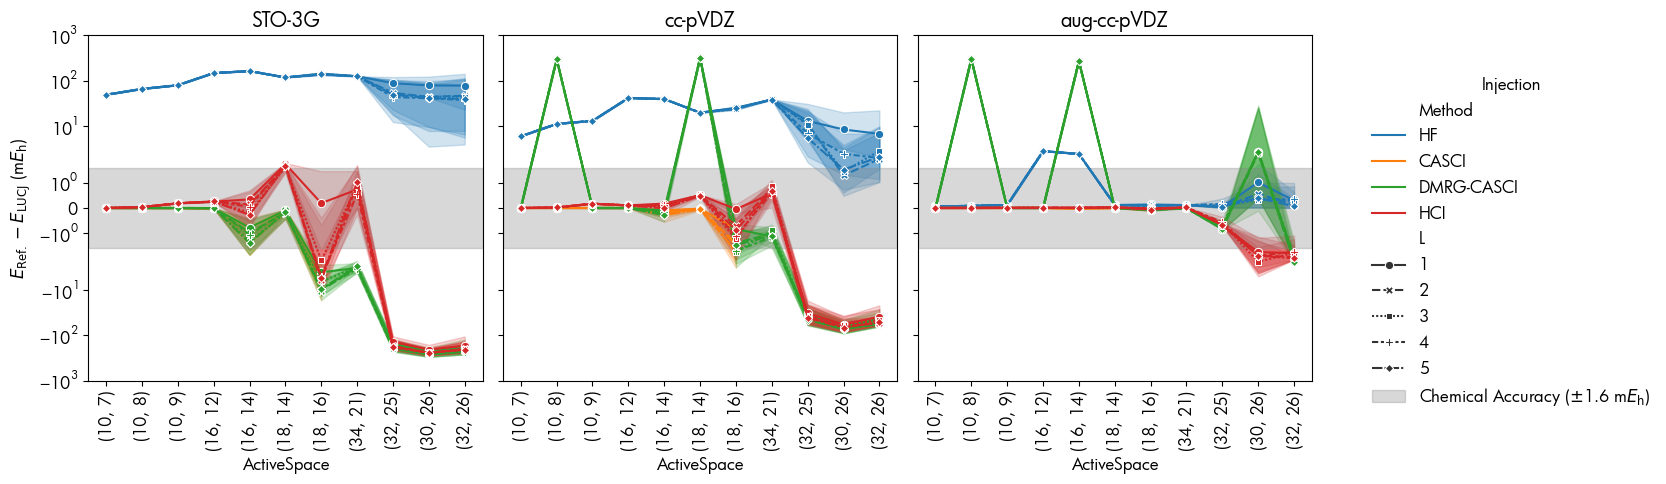

In [34]:
# --- 2. PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Loop through subplots using uniqueBasis
for ax, bs in zip(axes, uniqueBasis):
    # Filter for the specific basis set
    subset = meltedrefdevs[meltedrefdevs['Basis Set'] == bs]
    
    # Plot on the specific subplot
    sns.lineplot(
        data=subset,
        x='ActiveSpace',
        y='Deviation',
        hue='Method',
        style='L',
        legend=True,
        ax=ax,
        markers=True
    )
    
    ax.set_title(bs)
    ax.set_yscale("symlog")
    ax.axhspan(-1.6, 1.6, color="gray", alpha=0.3, label=r"Chemical Accuracy ($\pm$1.6 m$E_{\mathrm{h}}$)")
    ax.set_ylabel(r"$E_{\mathrm{Ref.}} - E_{\mathrm{LUCJ}}$ (m$E_{\mathrm{h}}$)")
    ax.set_ylim(-1e3, 1e3)
    
    # Rotate tick labels for each subplot
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Extract handles and labels from the last subplot
handles, labels = axes[-1].get_legend_handles_labels()

# Remove individual legends
for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

# Add the single shared legend
fig.legend(
    handles, labels, 
    title='Injection', 
    loc='center left', 
    bbox_to_anchor=(0.91, 0.5), 
    frameon=False
)

plt.tight_layout()
fig.subplots_adjust(right=0.88)  # Make room for external legend
plt.savefig("./GMJ_figures/DeviationsVsActiveSpaces.png", dpi=300, bbox_inches='tight')
plt.show()

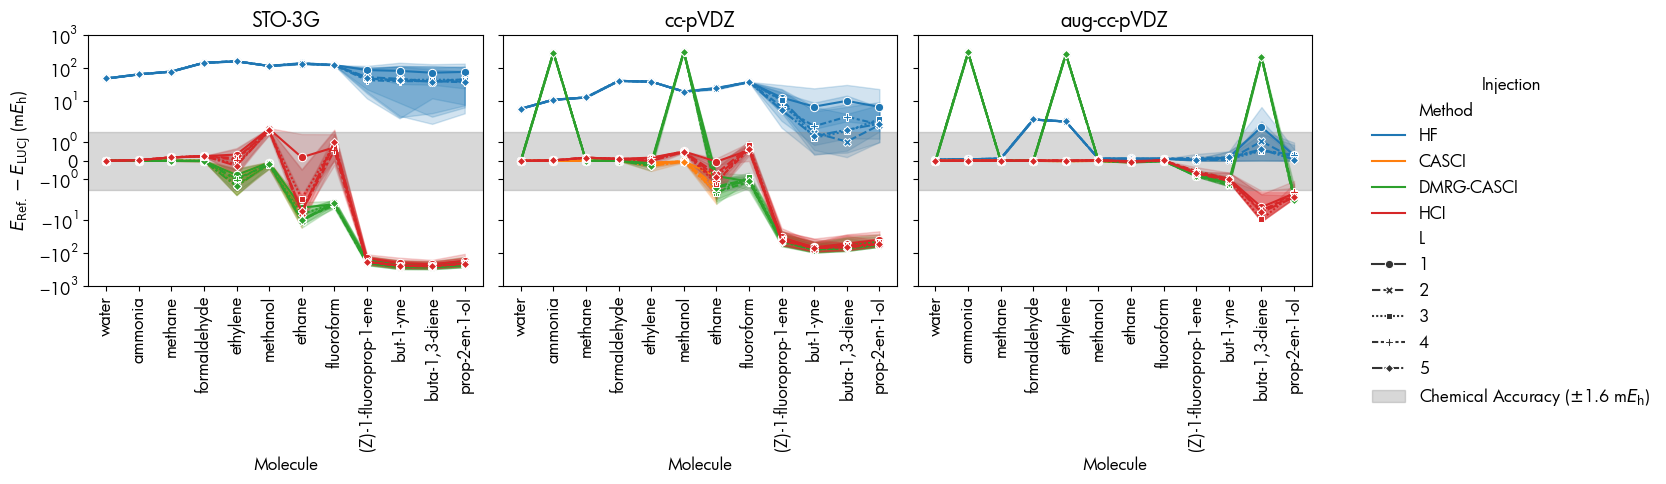

In [35]:
# --- 2. PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Loop through subplots using uniqueBasis
for ax, bs in zip(axes, uniqueBasis):
    # Filter for the specific basis set
    subset = meltedrefdevs[meltedrefdevs['Basis Set'] == bs]
    
    # Plot on the specific subplot
    sns.lineplot(
        data=subset,
        x='Molecule',
        y='Deviation',
        hue='Method',
        style='L',
        legend=True,
        ax=ax,
        markers=True
    )
    
    ax.set_title(bs)
    ax.set_yscale("symlog")
    ax.axhspan(-1.6, 1.6, color="gray", alpha=0.3, label=r"Chemical Accuracy ($\pm$1.6 m$E_{\mathrm{h}}$)")
    ax.set_ylabel(r"$E_{\mathrm{Ref.}} - E_{\mathrm{LUCJ}}$ (m$E_{\mathrm{h}}$)")
    ax.set_ylim(-1e3, 1e3)
    
    # Rotate tick labels for each subplot
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Extract handles and labels from the last subplot
handles, labels = axes[-1].get_legend_handles_labels()

# Remove individual legends
for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

# Add the single shared legend
fig.legend(
    handles, labels, 
    title='Injection', 
    loc='center left', 
    bbox_to_anchor=(0.91, 0.5), 
    frameon=False
)

plt.tight_layout()
fig.subplots_adjust(right=0.88)  # Make room for external legend
plt.savefig("./GMJ_figures/DeviationsVsMolecule.png", dpi=300, bbox_inches='tight')
plt.show()

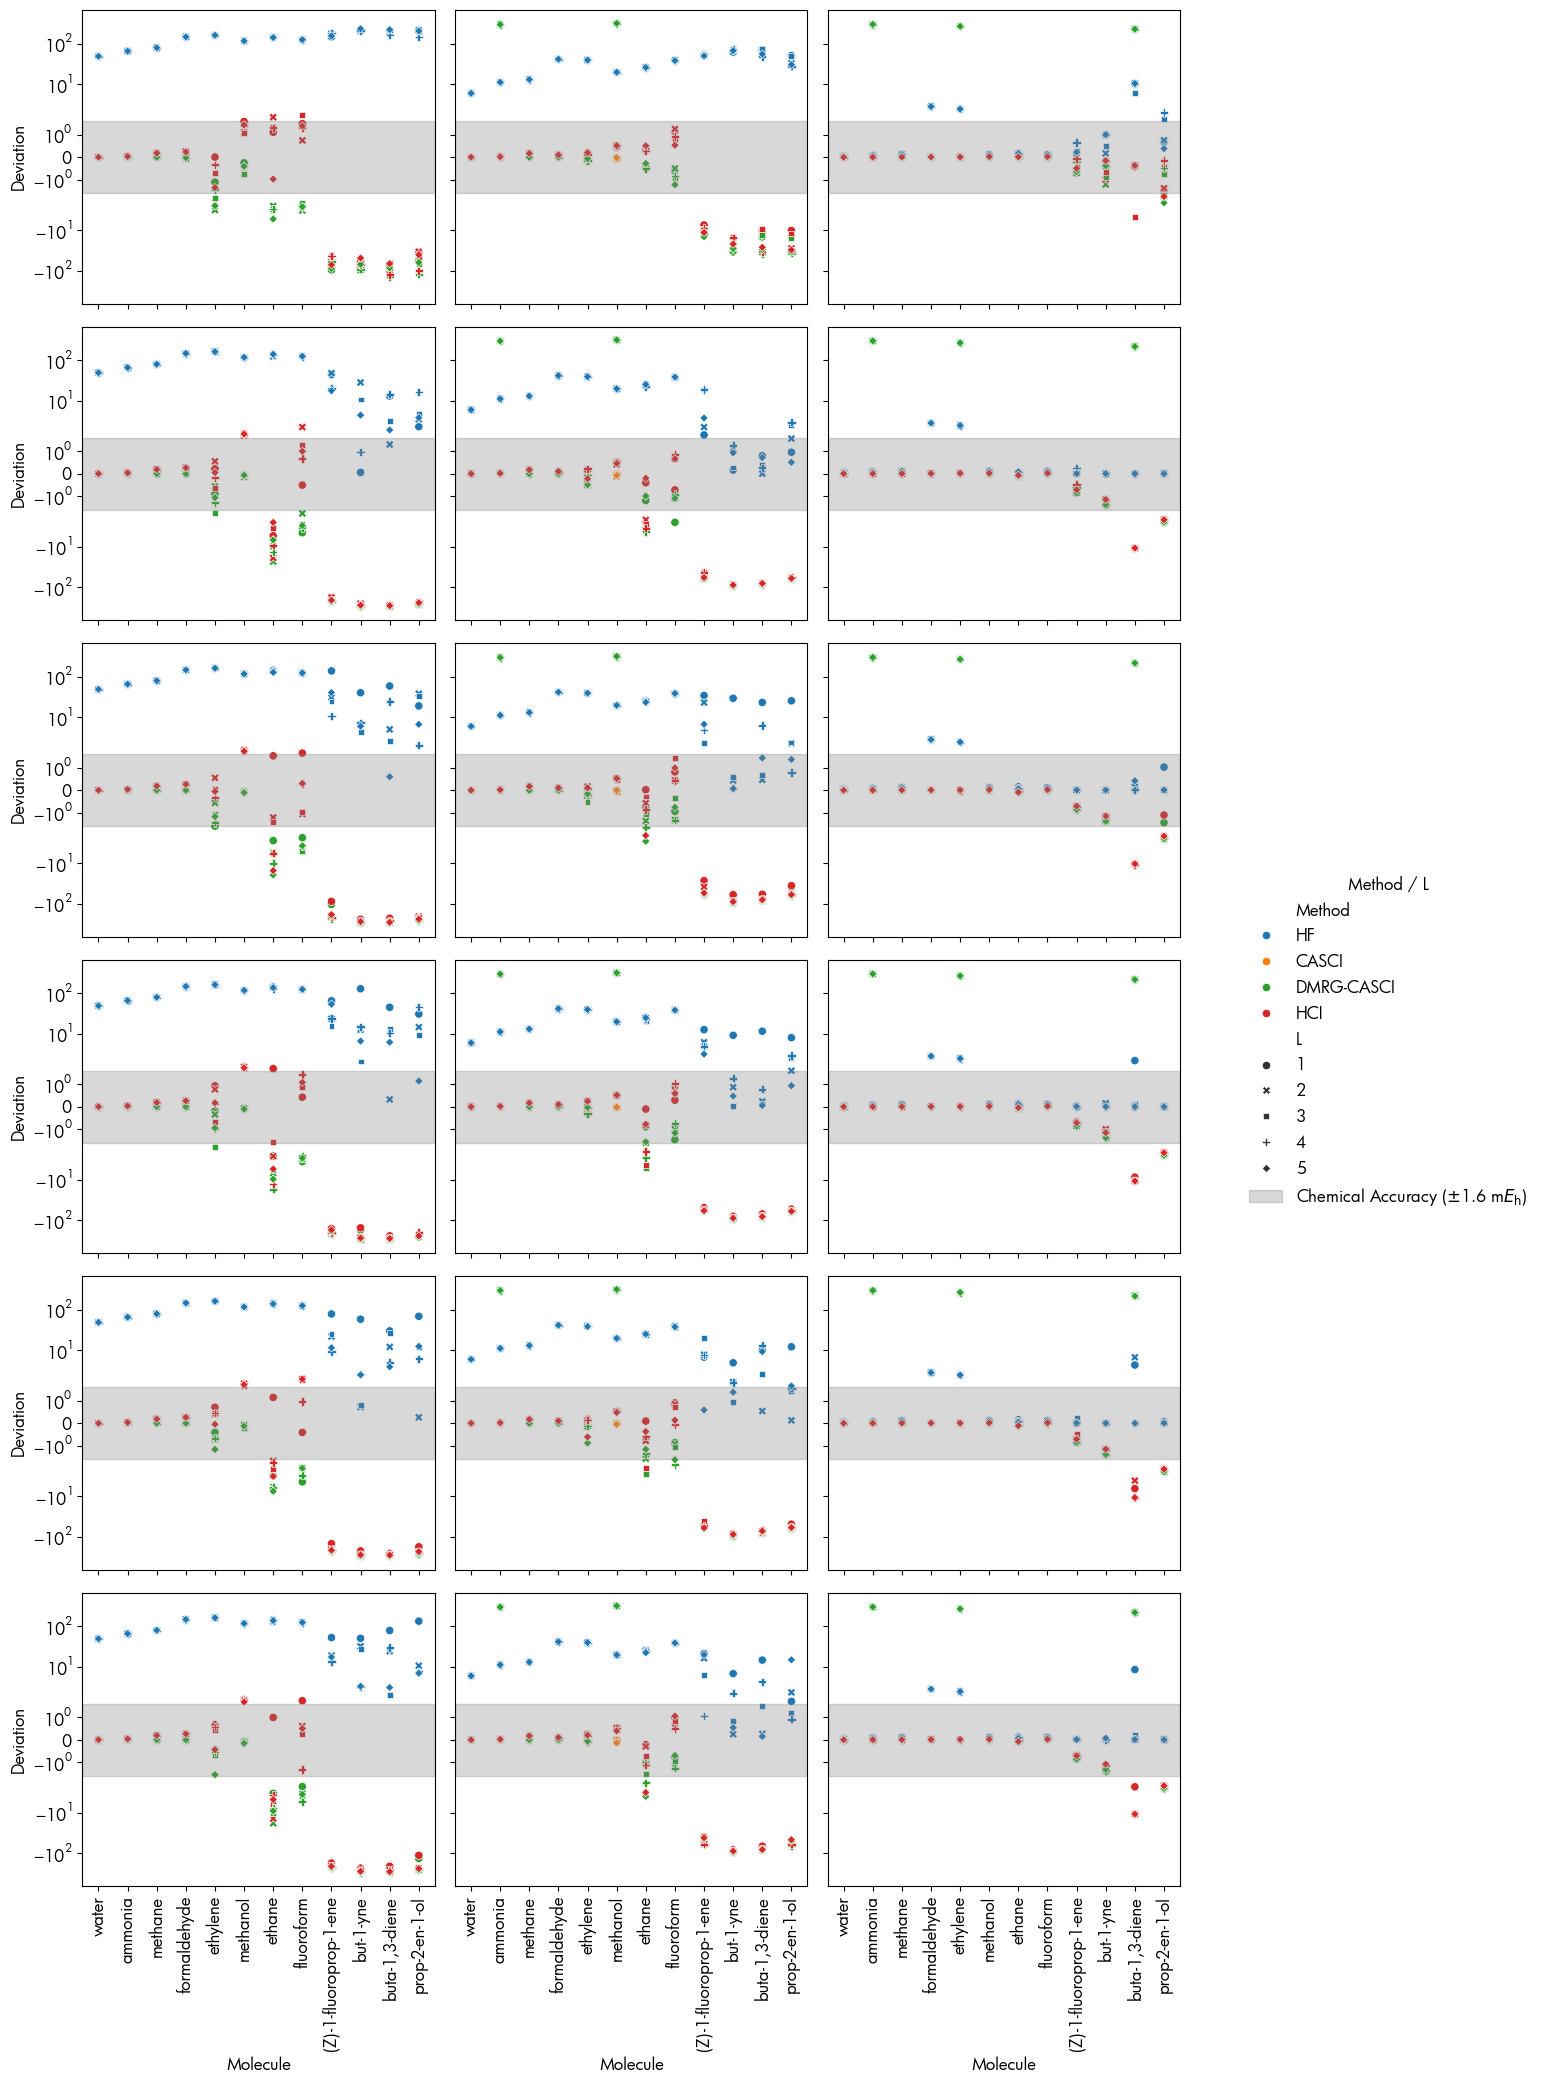

In [36]:
num_rows = len(uniqueInj)
num_cols = len(uniqueBasis)

# Create a grid of subplots (rows = uniqueInj, cols = uniqueBasis)
fig, axes = plt.subplots(
    num_rows, 
    num_cols, 
    figsize=(4.5 * num_cols, 3.5 * num_rows), 
    sharex=True, 
    sharey=True
)

# Convert axes to 2D array if either dimension is 1
axes = np.atleast_2d(axes)

for r, inj in enumerate(uniqueInj):
    for c, bs in enumerate(uniqueBasis):
        ax = axes[r, c]
        
        # Filter for specific Injection and Basis Set combination
        subset = meltedrefdevs[
            (meltedrefdevs['Injected'] == inj) & 
            (meltedrefdevs['Basis Set'] == bs)
        ]
        
        # Plot data
        sns.scatterplot(
            data=subset,
            x='Molecule',
            y='Deviation',
            hue='Method',
            style='L',
            legend=True,
            ax=ax
        )
        
        # # Set titles: Top row gets Basis Set, left column gets Injection label
        # if r == 0 and c == 0:
        #     ax.set_title(f"{bs}\n(Inj: {inj})", fontsize=11)
        # elif r == 0:
        #     ax.set_title(f"{bs}", fontsize=11)
        # elif c == 0:
        #     ax.set_title(f"Inj: {inj}", fontsize=11)

        ax.set_yscale("symlog")
        ax.axhspan(-1.6, 1.6, color="gray", alpha=0.3, label=r"Chemical Accuracy ($\pm$1.6 m$E_{\mathrm{h}}$)")
        
        # Rotate x-axis labels on the bottom row
        for label in ax.get_xticklabels():
            label.set_rotation(90)
            label.set_horizontalalignment("center")
            label.set_verticalalignment("top")

# Extract legend elements from the last subplot
handles, labels = axes[-1, -1].get_legend_handles_labels()

# Remove individual legends across the grid
for ax in axes.flat:
    if ax.get_legend():
        ax.get_legend().remove()

# Single shared legend for the entire grid
fig.legend(
    handles, labels, 
    title='Method / L', 
    loc='center left', 
    bbox_to_anchor=(0.92, 0.5), 
    frameon=False
)

plt.tight_layout()
fig.subplots_adjust(right=0.88)  # Leave space on the right for the shared legend
plt.show()

<Axes: xlabel='L', ylabel='Deviation'>

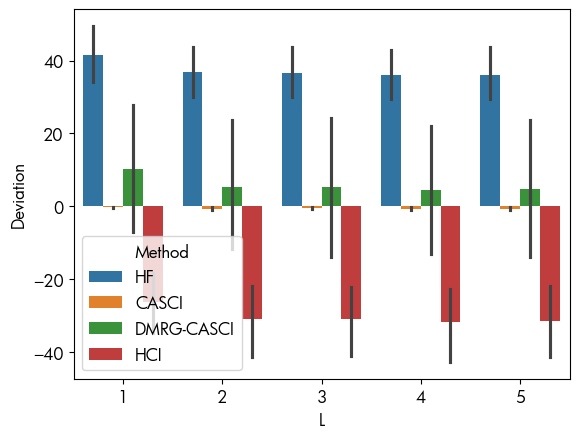

In [37]:
sns.barplot(meltedrefdevs,x='L',y='Deviation',hue='Method')

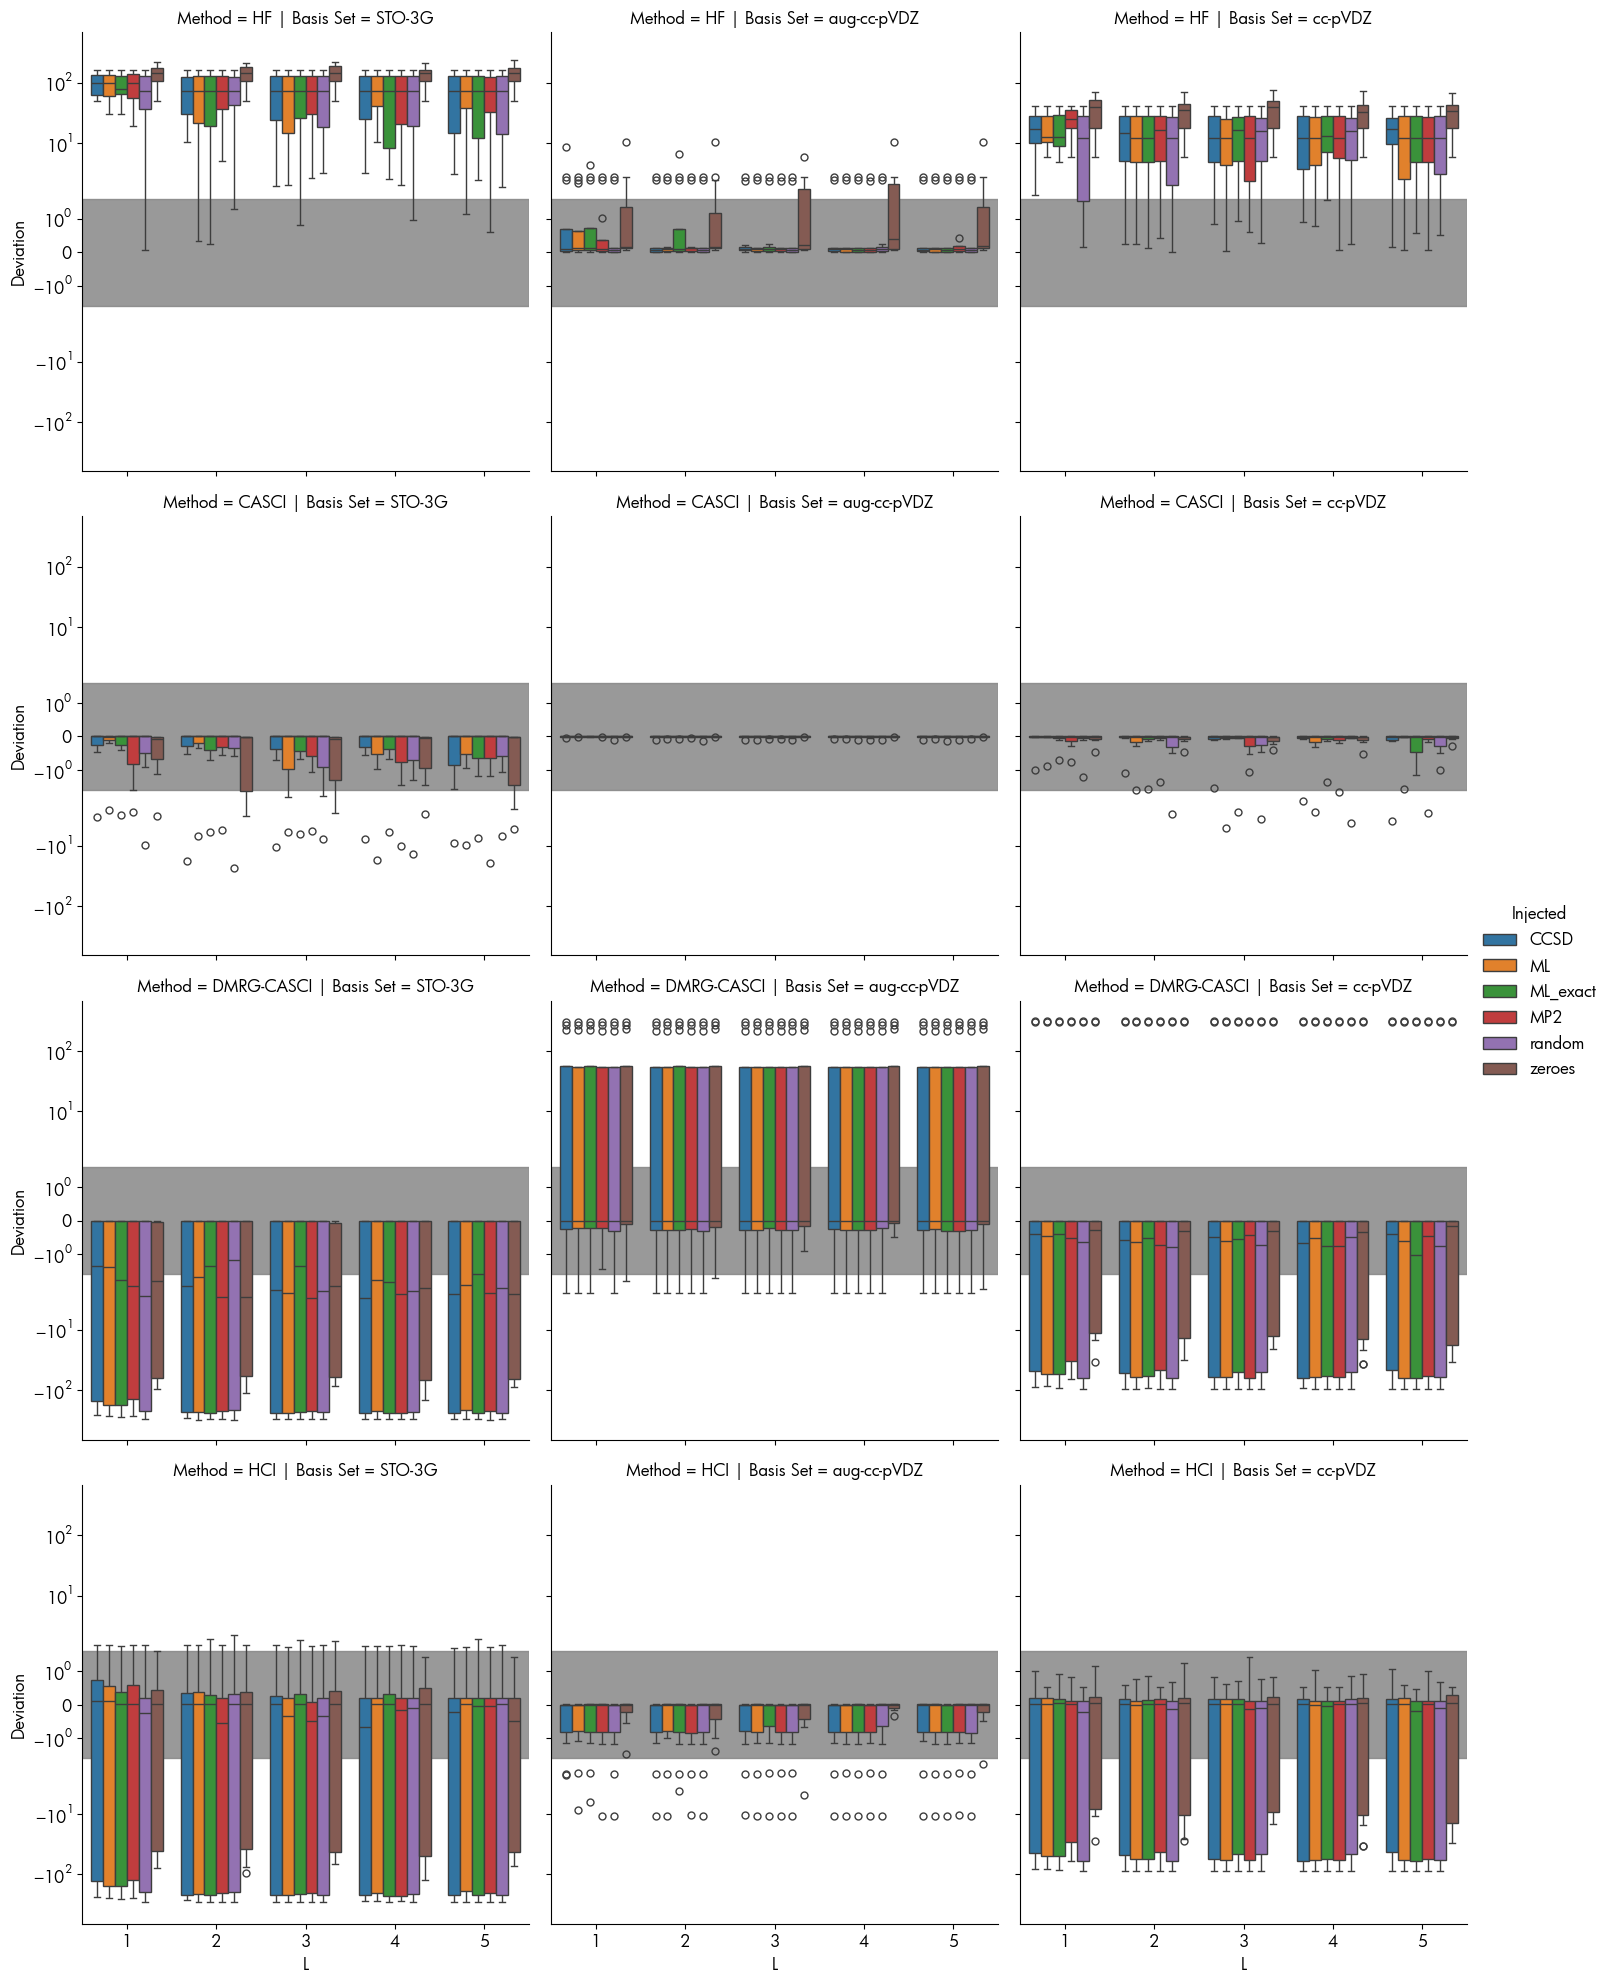

In [38]:
# If 'Molecule' is categorical strings and you want markers by 'style':
g = sns.catplot(
    data=meltedrefdevs,
    x="L",
    y="Deviation",
    row="Method",
    # style="L",
    col="Basis Set",
    hue="Injected",
    kind="box",
    # col_order=uniqueBasis,
    # row_order=uniqueInj
)
for ax in g.axes.flat:
    ax.set_yscale("symlog")

    ax.axhspan(-1.6,1.6,color="gray",alpha=0.8,label="Chemical Accuracy (1.6 mEh)")    

In [39]:
MAEvsRefs=[]
for energies in ["Energy (HF)", "Energy (CASCI)", "Energy (HCI)", "Energy (DMRG-CASCI)"]:
    methodname = energies.split()[1].strip('()')
    for basis in uniqueBasis:
        maskb = (LUCJDF["Basis Set"] == basis)
        b_df = LUCJDF.loc[maskb, ["Energy", energies]].dropna()
        if not b_df.empty:
            b_mae = mean_absolute_error(b_df["Energy"], b_df[energies]) *1e3
            print(f"{energies} | Basis: {basis} | MAE: {b_mae}")
#         for inj in uniqueInj:
#             maskinj = maskb & (LUCJDF["Injected"] == inj)
            
#             for l in uniqueLayers:
#                 # FIX: Updated to filter by "Layer" instead of repeating "Injected"
#                 maskl = maskinj & (LUCJDF["L"] == l) 
                
#                 # Extract the two columns matching your filter
#                 sub_df = LUCJDF.loc[maskl, ["Energy", energies]]
                
#                 # DROP NaN: Keep only rows where BOTH columns have valid numerical values
#                 sub_df_clean = sub_df.dropna()
                
#                 # Only calculate MAE if there is data left after dropping NaNs
#                 if not sub_df_clean.empty:
#                     mae = mean_absolute_error(sub_df_clean["Energy"], sub_df_clean[energies]) *1e3
#                     print(f"{energies} | Basis: {basis} | Inj: {inj} | Layer: {l} | MAE: {mae}")
#                     MAEvsRefs.append((methodname,basis,inj,l,mae))
#                 else:
#                     print(f"{energies} | Basis: {basis} | Inj: {inj} | Layer: {l} | MAE: No matching non-NaN data")
#                     MAEvsRefs.append((methodname,basis,inj,l,np.nan))

# refmaedf = pd.DataFrame(MAEvsRefs,columns=['Method','Basis','Injection','L','MAE'])



# ax = sns.catplot(
#     refmaedf,
#     row="Method",
#     col="Basis",
#     hue="L",
#     y="MAE",
#     x="Injection",
#     kind="bar",
#     col_order=uniqueBasis,
# )

# # Set log scale on all subplots
# # ax.set(yscale="log")

# # Add the gray shaded area for chemical accuracy (<= 1.6 mEh)
# # Note: Use ymax=1.6 if MAE is already in mEh, or ymax=1.6e-3 if MAE is in Hartrees (Eh)
# target_threshold = 1.6  # Adjust to 1.6 if y-axis is already in mEh

# for sub_ax in ax.axes.flat:
#     sub_ax.axhspan(
#         0,  # Bottom of shade
#         target_threshold,  # Top of shade (1.6 mEh)
#         color="gray",
#         alpha=0.8,  # Light transparency so bars remain visible
#         # zorder=0,  # Place behind the bars
#         label="Chemical Accuracy (1.6 mEh)" if sub_ax == ax.axes.flat[0] else "",
#     )

# plt.show()

Energy (HF) | Basis: STO-3G | MAE: 90.93431886862987
Energy (HF) | Basis: cc-pVDZ | MAE: 20.614885601517546
Energy (HF) | Basis: aug-cc-pVDZ | MAE: 0.7137235759182421
Energy (CASCI) | Basis: STO-3G | MAE: 1.3261270854047984
Energy (CASCI) | Basis: cc-pVDZ | MAE: 0.2795075139399641
Energy (CASCI) | Basis: aug-cc-pVDZ | MAE: 0.011850647769931366
Energy (HCI) | Basis: STO-3G | MAE: 70.75911225544878
Energy (HCI) | Basis: cc-pVDZ | MAE: 20.104964061513662
Energy (HCI) | Basis: aug-cc-pVDZ | MAE: 1.0074821339985127
Energy (DMRG-CASCI) | Basis: STO-3G | MAE: 77.57970768959989
Energy (DMRG-CASCI) | Basis: cc-pVDZ | MAE: 73.12752484843938
Energy (DMRG-CASCI) | Basis: aug-cc-pVDZ | MAE: 66.3706093583754


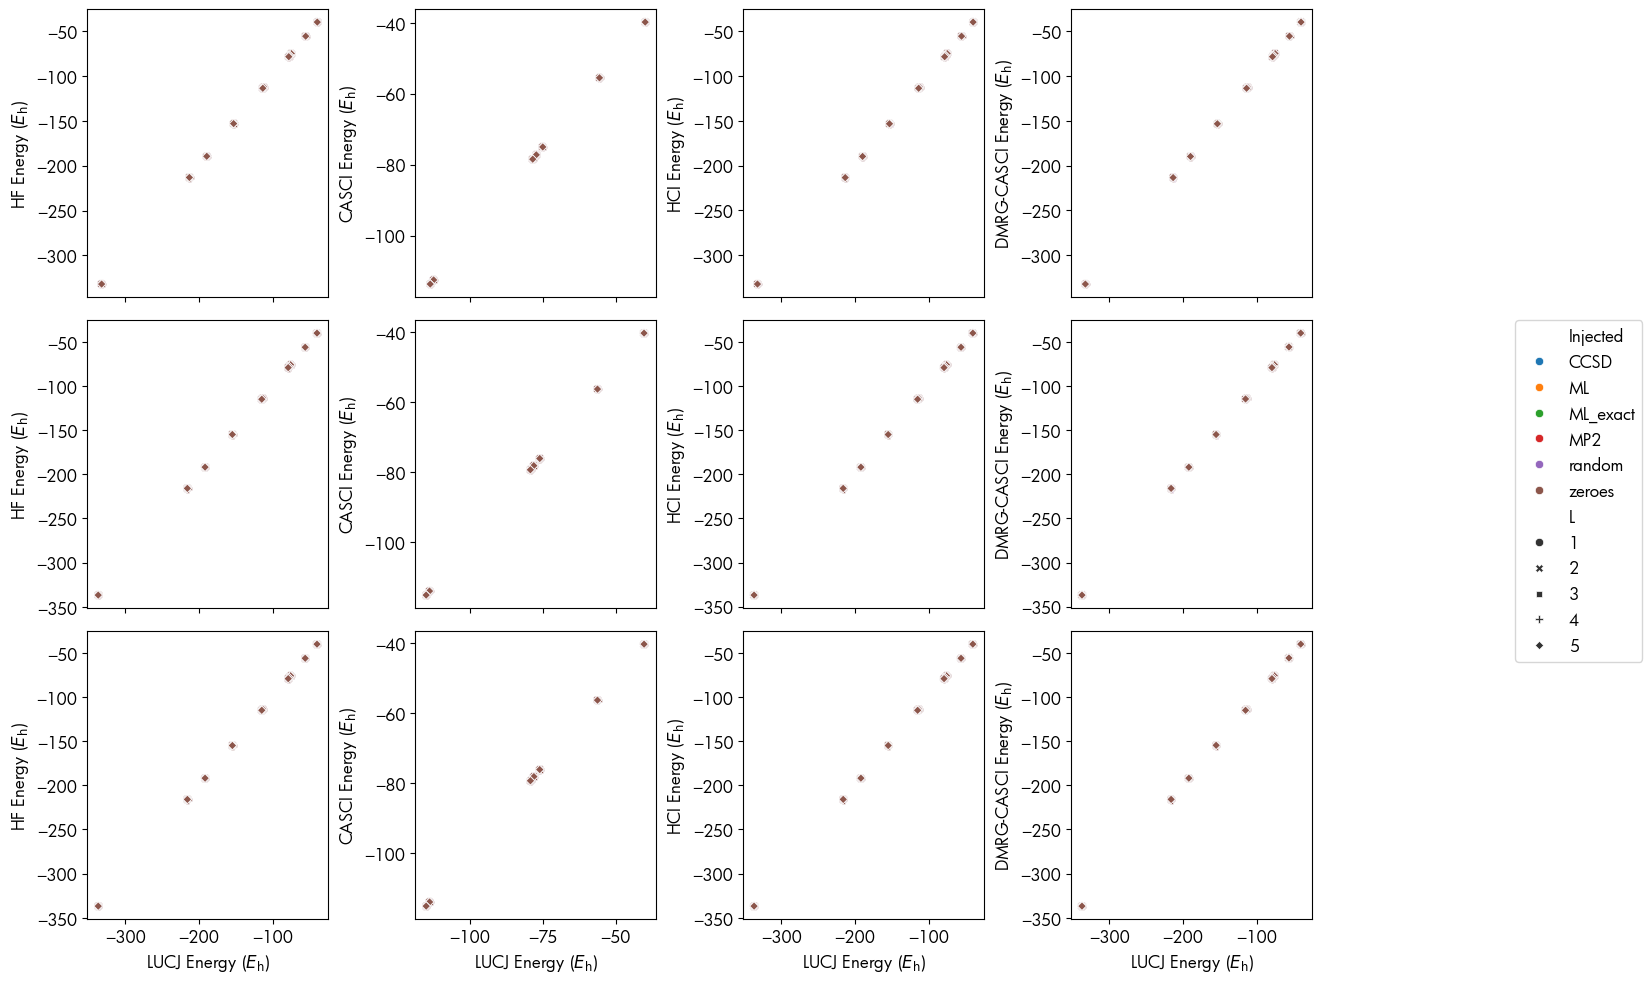

In [40]:
fig, ax = plt.subplots(len(uniqueBasis), 4, figsize=(15, 10), sharex="col")

for axrow, basis in enumerate(uniqueBasis):
    for axcol, Eother in enumerate(
        ["Energy (HF)", "Energy (CASCI)", "Energy (HCI)", "Energy (DMRG-CASCI)"]
    ):
        curr_ax = ax[axrow, axcol]

        # Only generate legend handle data on the very last subplot (bottom-right)
        is_last = (axrow == len(uniqueBasis) - 1) and (axcol == 3)

        sns.scatterplot(
            data=LUCJDF[LUCJDF["Basis Set"] == basis],
            x="Energy",
            y=Eother,
            ax=curr_ax,
            hue="Injected",
            style="L",
            legend="auto" if is_last else False,  # <--- Generate handles only once
        )

        curr_ax.set_xlabel(r"LUCJ Energy ($E_{\mathrm{h}}$)")
        curr_ax.set_ylabel(
            f"{Eother.split()[1].strip('()')} Energy" + r" ($E_{\mathrm{h}}$)"
        )

# Extract handles and labels from the last subplot
handles, labels = ax[-1, -1].get_legend_handles_labels()

# Remove the actual legend box from inside that last subplot
ax[-1, -1].get_legend().remove()

# Create the single figure-level legend on the outside
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True,
)

# Adjust layout so the outside legend isn't clipped
plt.tight_layout()
plt.subplots_adjust(right=0.88)

plt.show()

In [41]:
findDevCCSD = LUCJDF[['Basis Set','Molecule','L','Injected','Energy','n_atoms']].copy()

In [42]:
# uniqueBasis = LUCJDF['Basis Set'].unique()
for basis, mol, layer in product(uniqueBasis,uniqueMol,uniqueLayers):
    mask = (findDevCCSD['Basis Set']==basis)&(findDevCCSD['Molecule']==mol)&(findDevCCSD['L']==layer)
    # foundccsd = findDevCCSD.loc[mask]
    findDevCCSD.loc[mask,'Deviation'] = (findDevCCSD.loc[mask&(findDevCCSD['Injected'].isin(uniqueInj)),'Energy'] - findDevCCSD.loc[mask&(findDevCCSD['Injected']=='CCSD'),'Energy'].values) * 1e3
    # print(devfound)
# , 'CCSD']

In [43]:
findDevCCSD.loc[(findDevCCSD['Basis Set']=='STO-3G')&(findDevCCSD['Molecule']=='ammonia')]

,Basis Set,Molecule,L,Injected,Energy,n_atoms,Deviation
1007,STO-3G,ammonia,1,CCSD,-55.519929,4,0.00000
0,STO-3G,ammonia,1,ML,-55.519929,4,0.00000
222,STO-3G,ammonia,1,ML_exact,-55.519929,4,0.00000
960,STO-3G,ammonia,1,MP2,-55.519929,4,0.00000
479,STO-3G,ammonia,1,random,-55.519929,4,0.00000
478,STO-3G,ammonia,1,zeroes,-55.519928,4,0.00133
285,STO-3G,ammonia,2,CCSD,-55.519929,4,0.00000
229,STO-3G,ammonia,2,ML,-55.519929,4,0.00000
210,STO-3G,ammonia,2,ML_exact,-55.519929,4,0.00000
703,STO-3G,ammonia,2,MP2,-55.519929,4,0.00000


In [44]:
findDevCCSD

,Basis Set,Molecule,L,Injected,Energy,n_atoms,Deviation
503,STO-3G,water,1,CCSD,-75.009479,3,0.00000
258,STO-3G,water,1,ML,-75.009479,3,0.00000
729,STO-3G,water,1,ML_exact,-75.009479,3,0.00000
515,STO-3G,water,1,MP2,-75.009479,3,0.00000
484,STO-3G,water,1,random,-75.009479,3,0.00000
...,...,...,...,...,...,...,...
851,cc-pVDZ,"buta-1,3-diene",5,random,-154.934639,10,-0.56925
1013,cc-pVDZ,prop-2-en-1-ol,5,random,-191.937005,10,14.25486
62,cc-pVDZ,but-1-yne,5,zeroes,-154.978498,10,-66.56986
853,cc-pVDZ,"buta-1,3-diene",5,zeroes,-154.989076,10,-55.00597


/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_4679/4253153649.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(


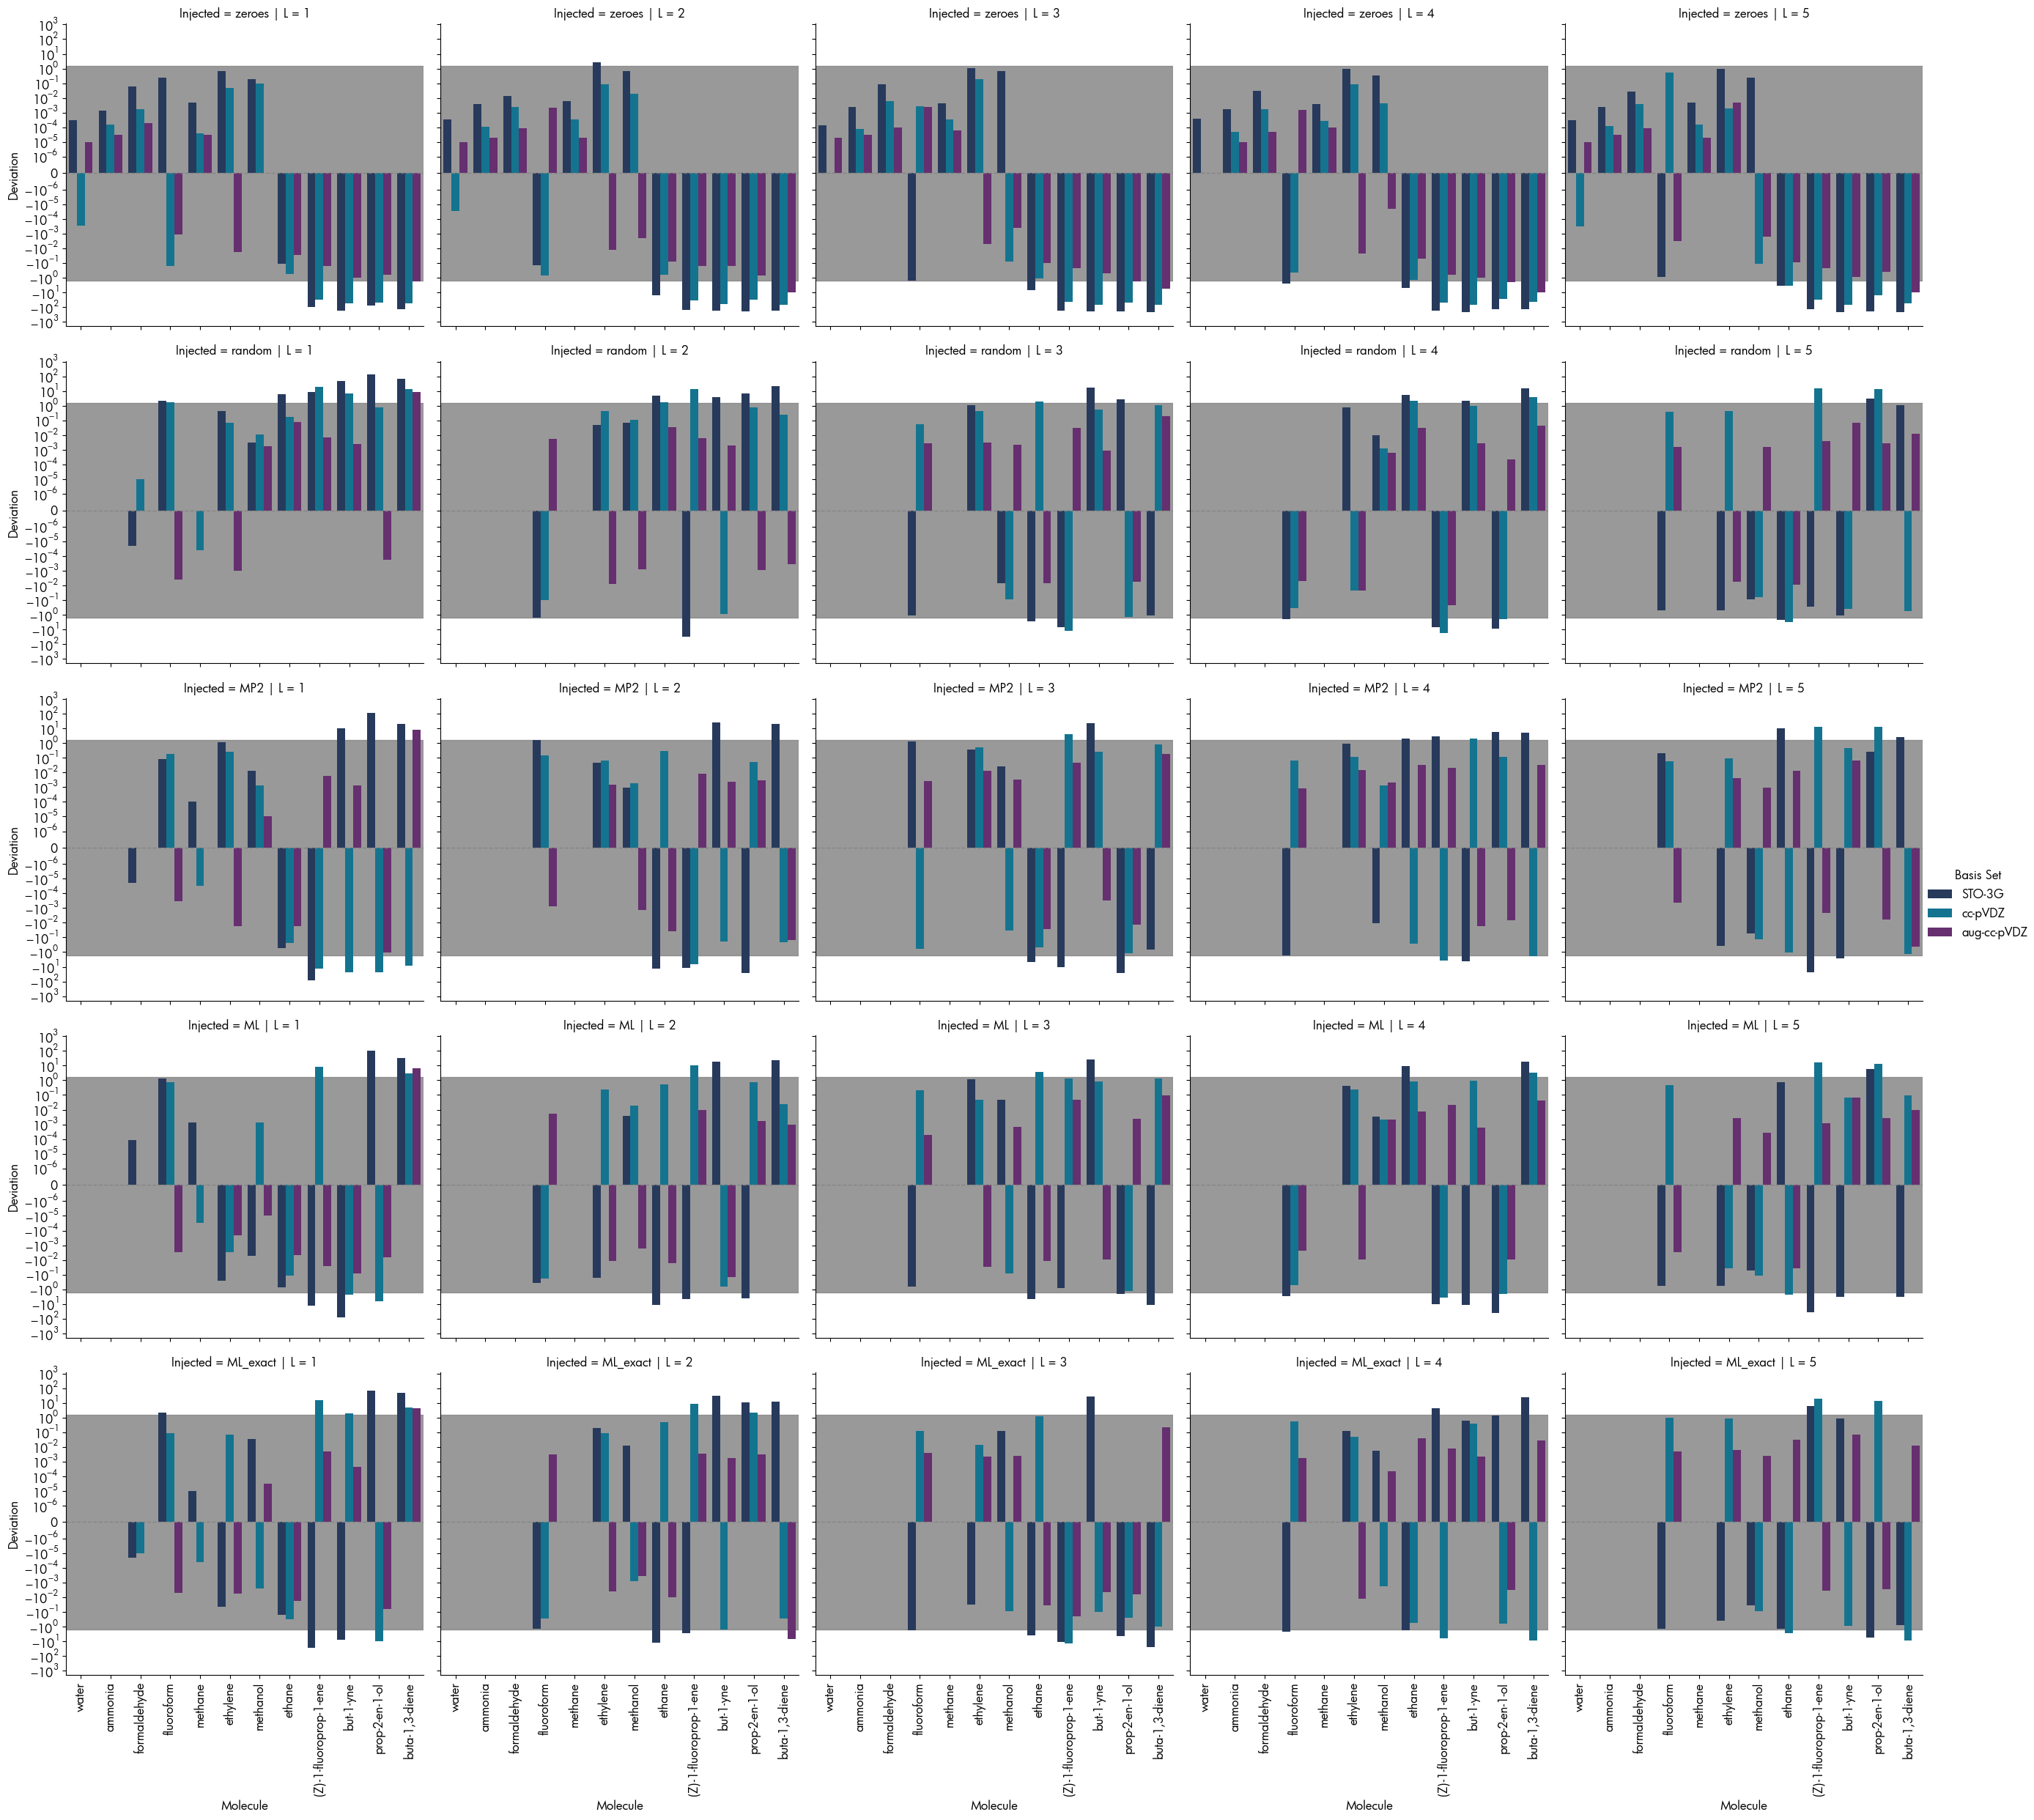

In [45]:


g = sns.catplot(
    data=findDevCCSD.loc[findDevCCSD['Injected'] != 'CCSD'].sort_values(by=['Basis Set','n_atoms','L']),
    hue='Basis Set',
    row='Injected',
    x='Molecule',
    y='Deviation',
    col='L',
    kind='bar',
    hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],
    row_order=['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],
    palette=palette
)

for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-6)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)  
plt.tight_layout()   
# plt.savefig("./GMJ_figures/DevEnergiesCCSDInitAll.png",dpi=300,bbox_inches='tight')

In [46]:
for inj, basis in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],uniqueBasis):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Basis Set'] == basis),'Deviation']
    print(inj,basis)
    print("min",findDevCCSD.loc[devfind.idxmin(),'Molecule'],f"{devfind.min():.2e}")
    print("max",findDevCCSD.loc[devfind.idxmax(),'Molecule'],f"{devfind.max():.2e}")
    print(devfind.describe().loc[['mean','min','max','std']].map('{:.2e}'.format))
    print(inj,basis,devfind[devfind.abs()>=1.6].shape[0])
    print()

zeroes STO-3G
min but-1-yne -2.31e+02
max ethylene 2.65e+00
mean    -5.73e+01
min     -2.31e+02
max      2.65e+00
std      8.40e+01
Name: Deviation, dtype: object
zeroes STO-3G 27

zeroes cc-pVDZ
min but-1-yne -7.39e+01
max fluoroform 5.22e-01
mean    -1.66e+01
min     -7.39e+01
max      5.22e-01
std      2.54e+01
Name: Deviation, dtype: object
zeroes cc-pVDZ 21

zeroes aug-cc-pVDZ
min buta-1,3-diene -1.03e+01
max ethylene 4.81e-03
mean    -8.23e-01
min     -1.03e+01
max      4.81e-03
std      2.35e+00
Name: Deviation, dtype: object
zeroes aug-cc-pVDZ 7

random STO-3G
min (Z)-1-fluoroprop-1-ene -2.89e+01
max prop-2-en-1-ol 1.32e+02
mean     4.81e+00
min     -2.89e+01
max      1.32e+02
std      2.06e+01
Name: Deviation, dtype: object
random STO-3G 24

random cc-pVDZ
min (Z)-1-fluoroprop-1-ene -1.76e+01
max (Z)-1-fluoroprop-1-ene 1.93e+01
mean     1.06e+00
min     -1.76e+01
max      1.93e+01
std      5.39e+00
Name: Deviation, dtype: object
random cc-pVDZ 15

random aug-cc-pVDZ
min (Z)-1-

In [47]:
layer_inj_dev = []
for inj, layers in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],sorted(uniqueLayers)):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['L'] == layers),'Deviation']
    layer_inj_dev.append((inj,layers,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2))
    print(inj,layers,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2)
    # print()

zeroes 1 75.0
zeroes 2 69.44444444444444
zeroes 3 66.66666666666666
zeroes 4 66.66666666666666
zeroes 5 69.44444444444444
random 1 69.44444444444444
random 2 77.77777777777779
random 3 83.33333333333334
random 4 72.22222222222221
random 5 86.11111111111111
MP2 1 75.0
MP2 2 80.55555555555556
MP2 3 86.11111111111111
MP2 4 75.0
MP2 5 83.33333333333334
ML 1 75.0
ML 2 83.33333333333334
ML 3 86.11111111111111
ML 4 75.0
ML 5 80.55555555555556
ML_exact 1 72.22222222222221
ML_exact 2 77.77777777777779
ML_exact 3 80.55555555555556
ML_exact 4 83.33333333333334
ML_exact 5 83.33333333333334


In [48]:
mol_dev = []
for mol in uniqueMol:
    devfind = findDevCCSD.loc[(findDevCCSD['Molecule'] == mol),'Deviation']
    mol_dev.append((mol,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2))
    # print()

moldevdf = pd.DataFrame(mol_dev).sort_values(by=[1])
moldevdf['n_atoms'] = moldevdf[0].map(n_atoms_dict)    
# moldevdf[[0,1]].to_clipboard()

In [49]:
for inj, mol in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],uniqueMol):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Molecule'] == mol),'Deviation']
    print(inj,mol,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2)
    # print()

zeroes water 100.0
zeroes ammonia 100.0
zeroes formaldehyde 100.0
zeroes fluoroform 86.66666666666667
zeroes methane 100.0
zeroes ethylene 93.33333333333333
zeroes methanol 100.0
zeroes ethane 66.66666666666666
zeroes (Z)-1-fluoroprop-1-ene 33.33333333333333
zeroes but-1-yne 33.33333333333333
zeroes buta-1,3-diene 0.0
zeroes prop-2-en-1-ol 20.0
random water 100.0
random ammonia 100.0
random formaldehyde 100.0
random fluoroform 73.33333333333333
random methane 100.0
random ethylene 100.0
random methanol 100.0
random ethane 40.0
random (Z)-1-fluoroprop-1-ene 40.0
random but-1-yne 66.66666666666666
random buta-1,3-diene 60.0
random prop-2-en-1-ol 53.333333333333336
MP2 water 100.0
MP2 ammonia 100.0
MP2 formaldehyde 100.0
MP2 fluoroform 86.66666666666667
MP2 methane 100.0
MP2 ethylene 100.0
MP2 methanol 100.0
MP2 ethane 73.33333333333333
MP2 (Z)-1-fluoroprop-1-ene 33.33333333333333
MP2 but-1-yne 53.333333333333336
MP2 buta-1,3-diene 53.333333333333336
MP2 prop-2-en-1-ol 60.0
ML water 100.0

In [50]:
for inj, basis in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],uniqueBasis):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Basis Set'] == basis),'Deviation']
    print(inj,basis,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2)
    # print()

zeroes STO-3G 55.00000000000001
zeroes cc-pVDZ 65.0
zeroes aug-cc-pVDZ 88.33333333333333
random STO-3G 60.0
random cc-pVDZ 75.0
random aug-cc-pVDZ 98.33333333333333
MP2 STO-3G 60.0
MP2 cc-pVDZ 81.66666666666667
MP2 aug-cc-pVDZ 98.33333333333333
ML STO-3G 61.66666666666667
ML cc-pVDZ 80.0
ML aug-cc-pVDZ 98.33333333333333
ML_exact STO-3G 63.33333333333333
ML_exact cc-pVDZ 78.33333333333333
ML_exact aug-cc-pVDZ 96.66666666666667


/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_4679/1039327296.py:2: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(


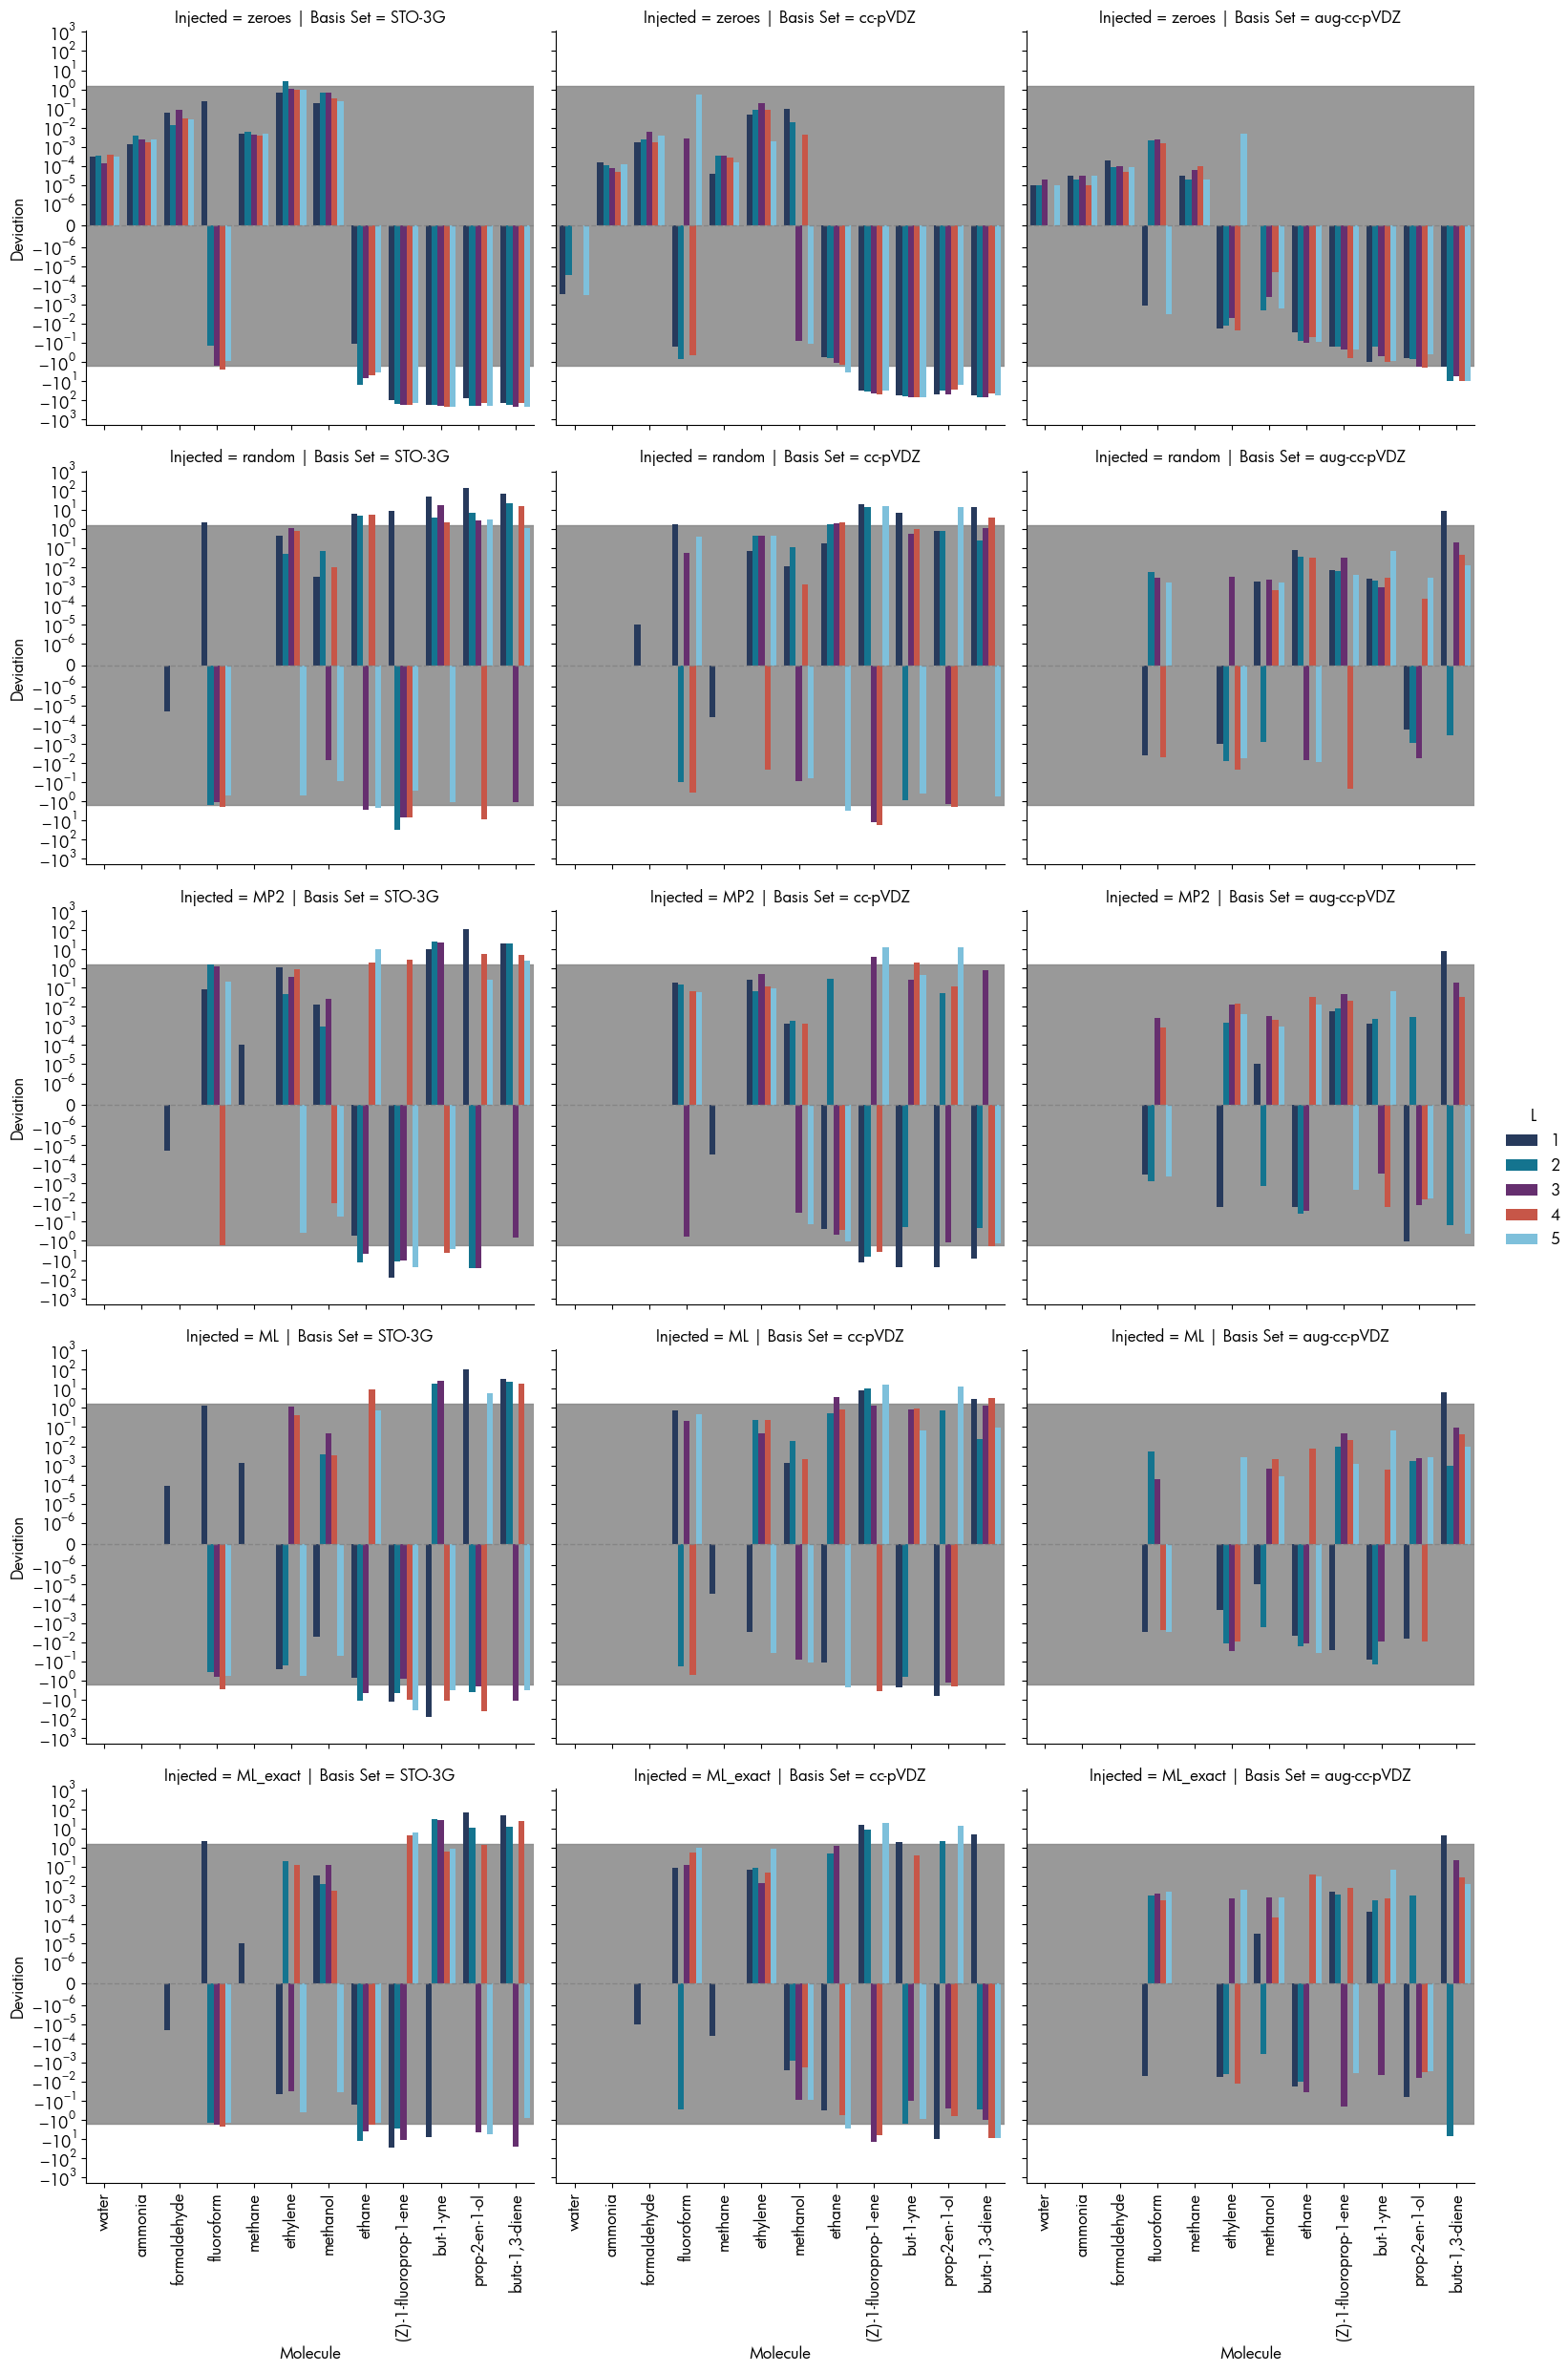

In [51]:
# 1. Generate your catplot and store it in a variable (g)
g = sns.catplot(
    data=findDevCCSD.loc[findDevCCSD['Injected'] != 'CCSD'].sort_values(by=['Basis Set','n_atoms','L']),
    col='Basis Set',
    row='Injected',
    x='Molecule',
    y='Deviation',
    hue='L',
    kind='bar',
    row_order=['zeroes','random','MP2','ML','ML_exact'],
    col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],
    palette=palette
)
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-6)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)  
plt.tight_layout()   
# # 2. Define a helper function to apply the gray span and axis scaling to each facet
# def customize_facet(*args, **kwargs):
#     ax = plt.gca()
#     # Add the gray area for chemical accuracy (~1 kcal/mol or 1.6 mHa depending on your units)
#     ax.axhspan(-1.6, 1.6, color='gray', alpha=0.3, zorder=0) # Lowered alpha to 0.3 so bars remain visible
    
#     # Apply symlog scaling and limits
#     ax.set_yscale("symlog", linthresh=1e-12)
#     ax.set_ylim(-1e3, 1e3)

# # 3. Map the custom function across all subplots in the FacetGrid
# g.map_dataframe(customize_facet)
plt.savefig("./GMJ_figures/DevEnergiesCCSDInitAll.png",dpi=300,bbox_inches='tight')
# Display the plot
plt.show()

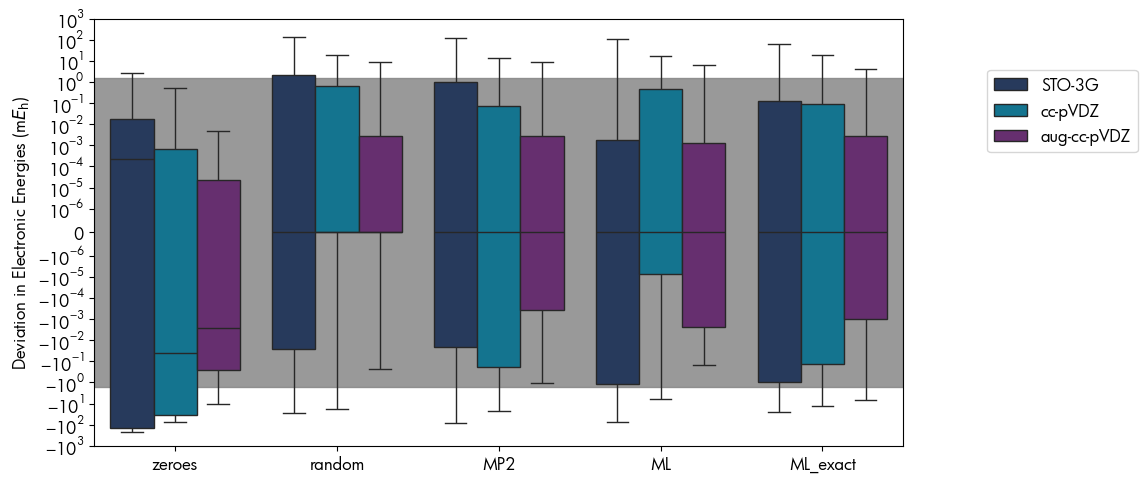

In [52]:

plt.figure(figsize=(12,5))
sns.boxplot(findDevCCSD,x='Injected',y='Deviation',hue='Basis Set',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette[0:3],order=['zeroes','random','MP2','ML','ML_exact'],whis=(0, 100))
plt.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
plt.yscale("symlog",linthresh=1e-6)
plt.ylim(-1e3,1e3)
plt.xlabel("")
plt.ylabel(r"Deviation in Electronic Energies (m$E_{\mathrm{h}}$)")
plt.legend(bbox_to_anchor=(1.3, 0.9))
plt.tight_layout()
plt.savefig("./GMJ_figures/DevEnergiesCCSDInit.png",dpi=300,bbox_inches='tight')
plt.show()

In [53]:
for inj in uniqueInj:
    for basis in uniqueBasis:
        devdf = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Basis Set']==basis),'Deviation']
        print(inj)
        print(devdf.describe().loc[['mean','min','max','std']].map('{:.2e}'.format))
        print(devdf.idxmin(),findDevCCSD.loc[findDevCCSD['Injected'] == inj].loc[devdf.idxmin()])

zeroes
mean    -5.73e+01
min     -2.31e+02
max      2.65e+00
std      8.40e+01
Name: Deviation, dtype: object
9 Basis Set        STO-3G
Molecule      but-1-yne
L                     5
Injected         zeroes
Energy      -153.259322
n_atoms              10
Deviation    -231.16019
Name: 9, dtype: object
zeroes
mean    -1.66e+01
min     -7.39e+01
max      5.22e-01
std      2.54e+01
Name: Deviation, dtype: object
507 Basis Set       cc-pVDZ
Molecule      but-1-yne
L                     3
Injected         zeroes
Energy      -154.986102
n_atoms              10
Deviation     -73.86788
Name: 507, dtype: object
zeroes
mean    -8.23e-01
min     -1.03e+01
max      4.81e-03
std      2.35e+00
Name: Deviation, dtype: object
146 Basis Set       aug-cc-pVDZ
Molecule     buta-1,3-diene
L                         2
Injected             zeroes
Energy          -154.950256
n_atoms                  10
Deviation         -10.34143
Name: 146, dtype: object
random
mean     4.81e+00
min     -2.89e+01
max      1.3

In [54]:
# 1. Individual dictionaries for each level (summary stats)
basis_mae = {}
mol_mae = {}
inj_mae = {}
layer_mae = {}

# 2. The master compiled dictionary (nested)
all_mae = {}

for basis in uniqueBasis:
    b_mask = (LUCJDF['Basis Set'] == basis)
    basis_mae[basis] = mean_absolute_error(LUCJDF.loc[b_mask, 'Energy'], LUCJDF.loc[b_mask, 'Energy (HCI)']) * 1e3
    
    all_mae[basis] = {} # Initialize next level
    
    for mol in uniqueMol:
        m_mask = (LUCJDF['Molecule'] == mol)
        # Unique dict for molecules (could use a tuple key to keep it unique across basis sets)
        mol_mae[(basis, mol)] = mean_absolute_error(LUCJDF.loc[b_mask & m_mask, 'Energy'], LUCJDF.loc[b_mask & m_mask, 'Energy (HCI)']) * 1e3
        
        all_mae[basis][mol] = {}
        
        for inj in uniqueInj:
            i_mask = (LUCJDF['Injected'] == inj)
            inj_mae[(basis, mol, inj)] = mean_absolute_error(LUCJDF.loc[b_mask & m_mask & i_mask, 'Energy'], LUCJDF.loc[b_mask & m_mask & i_mask, 'Energy (HCI)']) * 1e3
            
            all_mae[basis][mol][inj] = {}
            
            for L in uniqueLayers:
                l_mask = (LUCJDF['L'] == L)
                
                # Check to avoid errors if a specific slice is empty
                subset = LUCJDF.loc[b_mask & m_mask & i_mask & l_mask]
                if not subset.empty:
                    mae_val = mean_absolute_error(subset['Energy'], subset['Energy (HCI)']) * 1e3
                    
                    # Store in unique flat dict
                    layer_mae[(basis, mol, inj, L)] = mae_val
                    
                    # Store in the compiled nested dict
                    all_mae[basis][mol][inj][L] = mae_val

# 1. Basis MAE (Keys are single strings)
basis_mae_df = pd.DataFrame(list(basis_mae.items()), 
                            columns=['Basis', 'MAE'])

# 2. Molecule MAE (Keys are tuples: (basis, mol))
mol_mae_df = pd.DataFrame([(*k, v) for k, v in mol_mae.items()], 
                          columns=['Basis', 'Molecule', 'MAE'])

# 3. Injected MAE (Keys are tuples: (basis, mol, inj))
inj_mae_df = pd.DataFrame([(*k, v) for k, v in inj_mae.items()], 
                          columns=['Basis', 'Molecule', 'Injected', 'MAE'])

# 4. Layer MAE (Keys are tuples: (basis, mol, inj, L))
layer_mae_df = pd.DataFrame([(*k, v) for k, v in layer_mae.items()], 
                            columns=['Basis', 'Molecule', 'Injected', 'L', 'MAE'])                    

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_4679/2530434211.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(data=layer_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',row='L',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette)


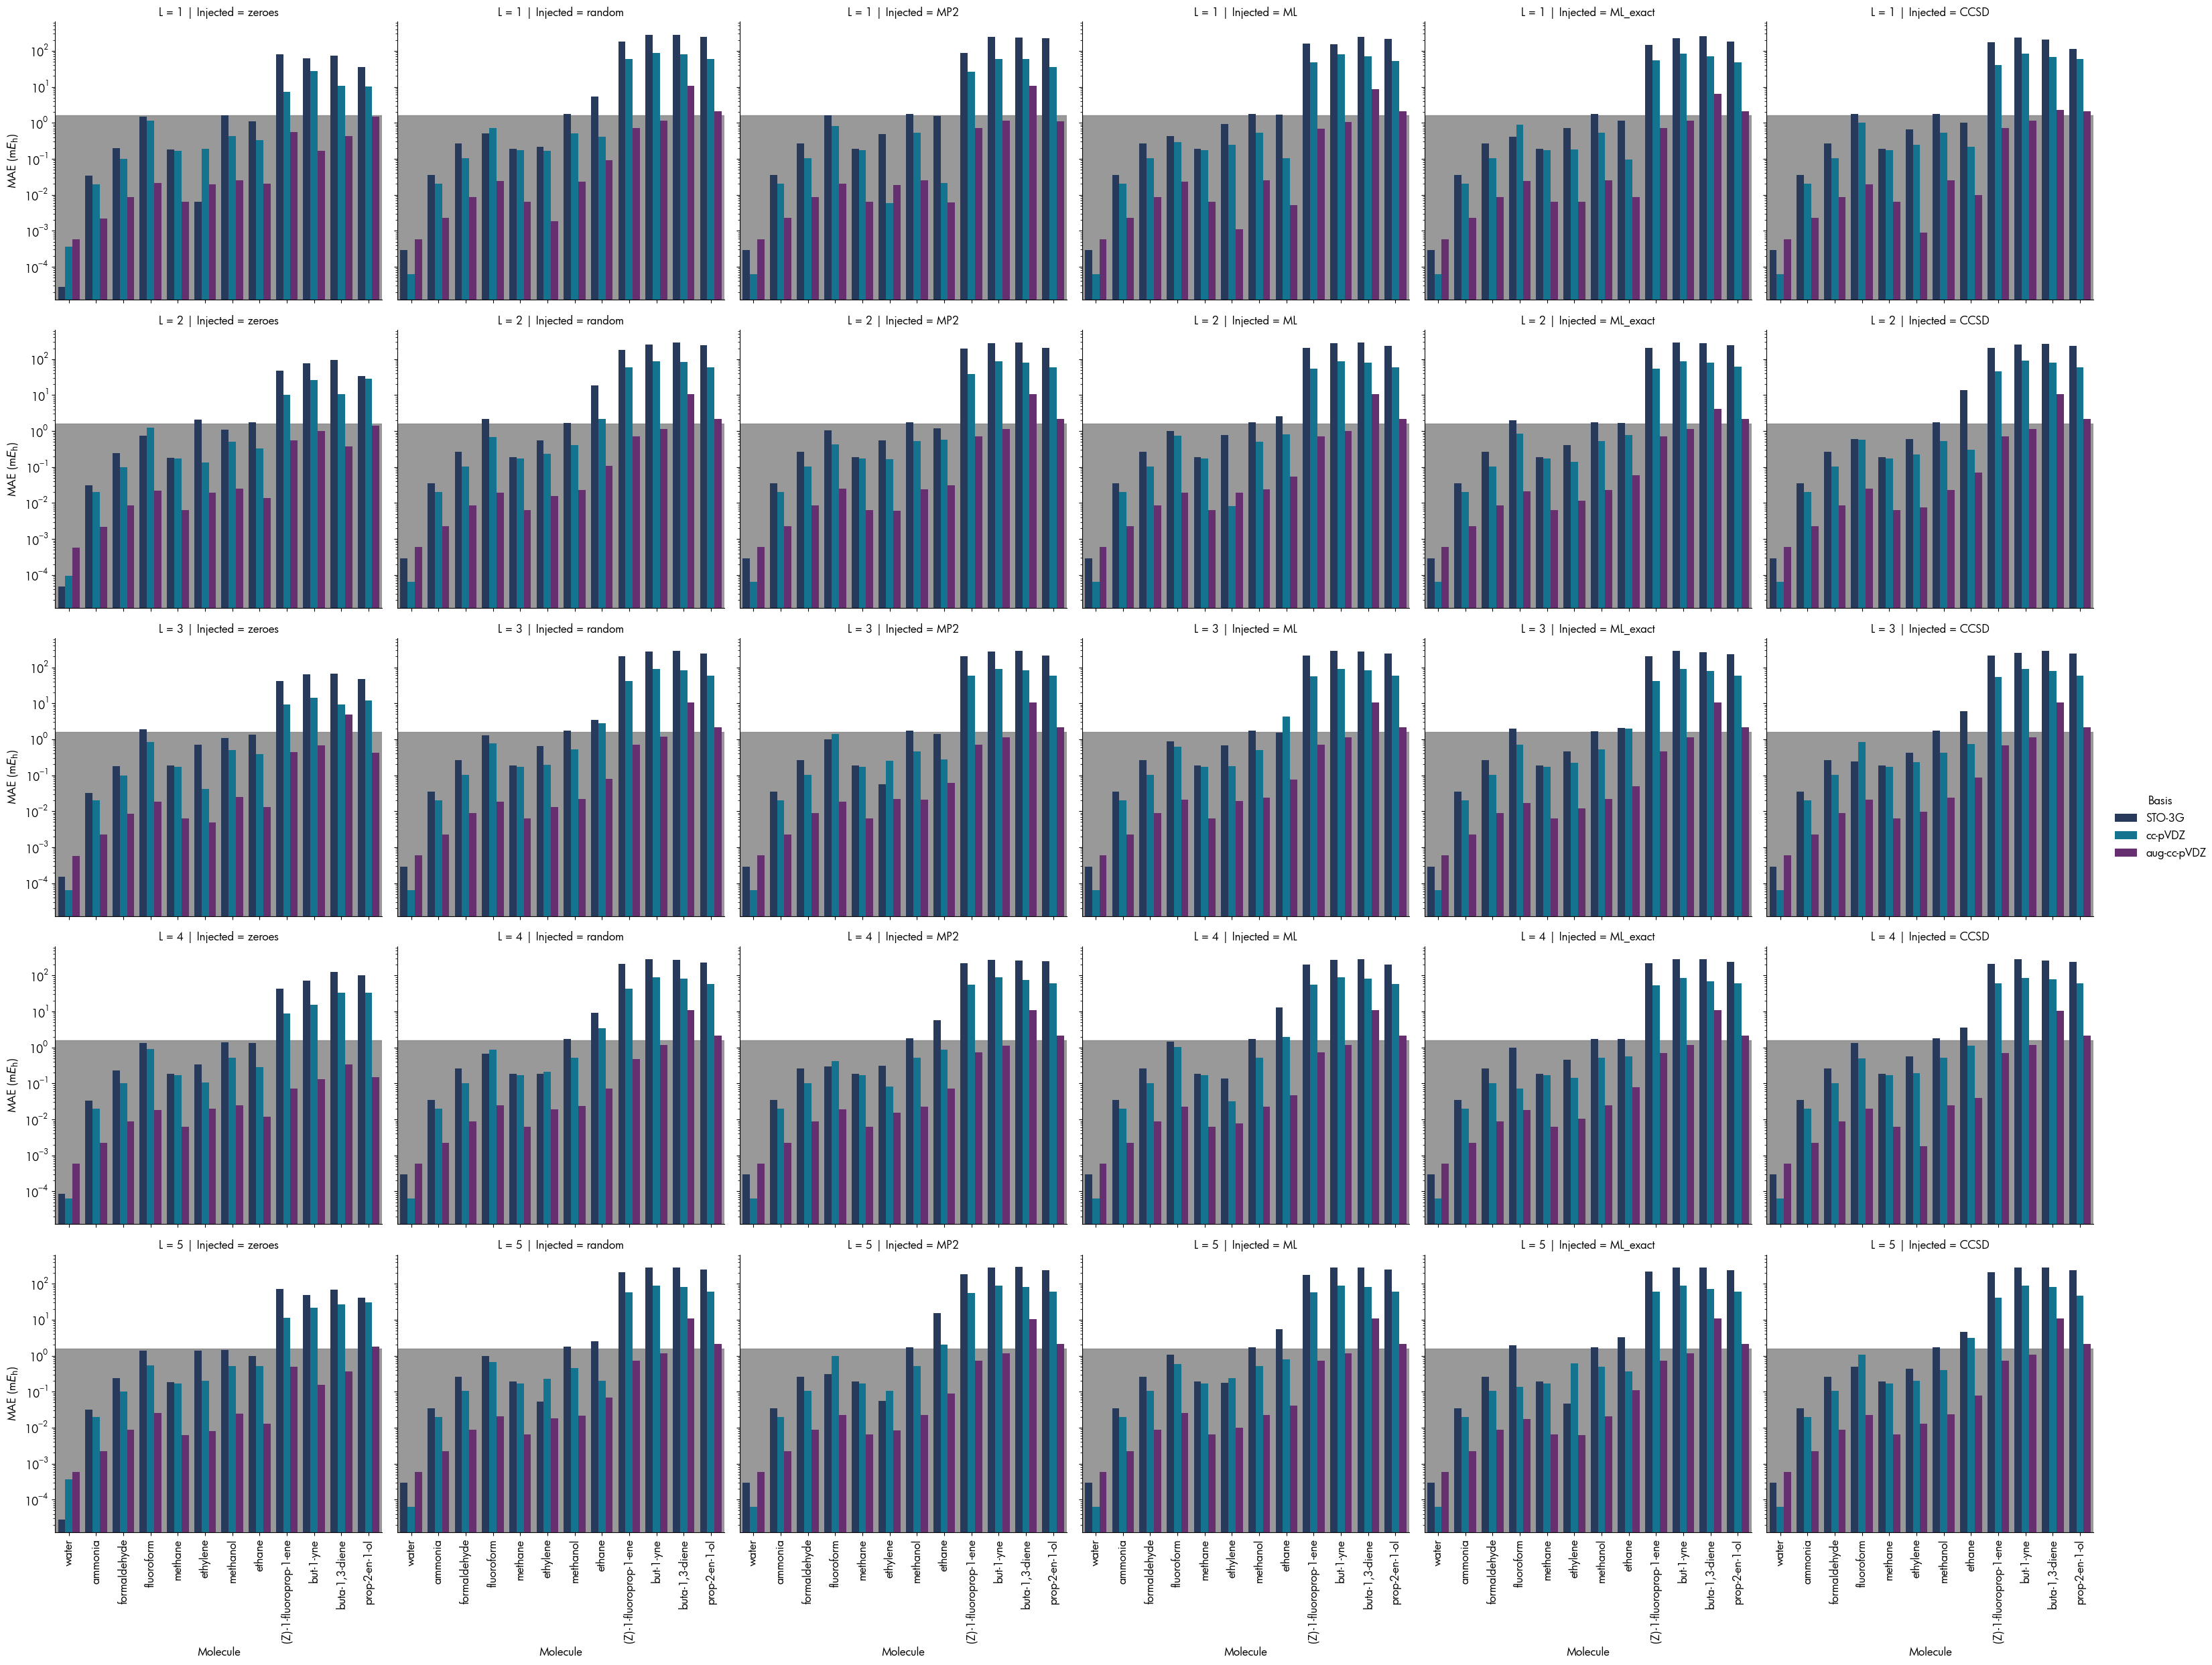

In [55]:
g = sns.catplot(data=layer_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',row='L',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette)
for ax in g.axes.flat:
    ax.set_yscale("log")
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(r"MAE (m$E_{\mathrm{h}}$)")
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)        
# plt.legend(loc='center right', bbox_to_anchor=(1.5, 0.5))        
plt.tight_layout()        
plt.savefig("GMJ_figures/MAE_inj_mol_basis_layer.png",dpi=300,bbox_inches='tight')

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_4679/1137384109.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(data=inj_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette,col_wrap=3)


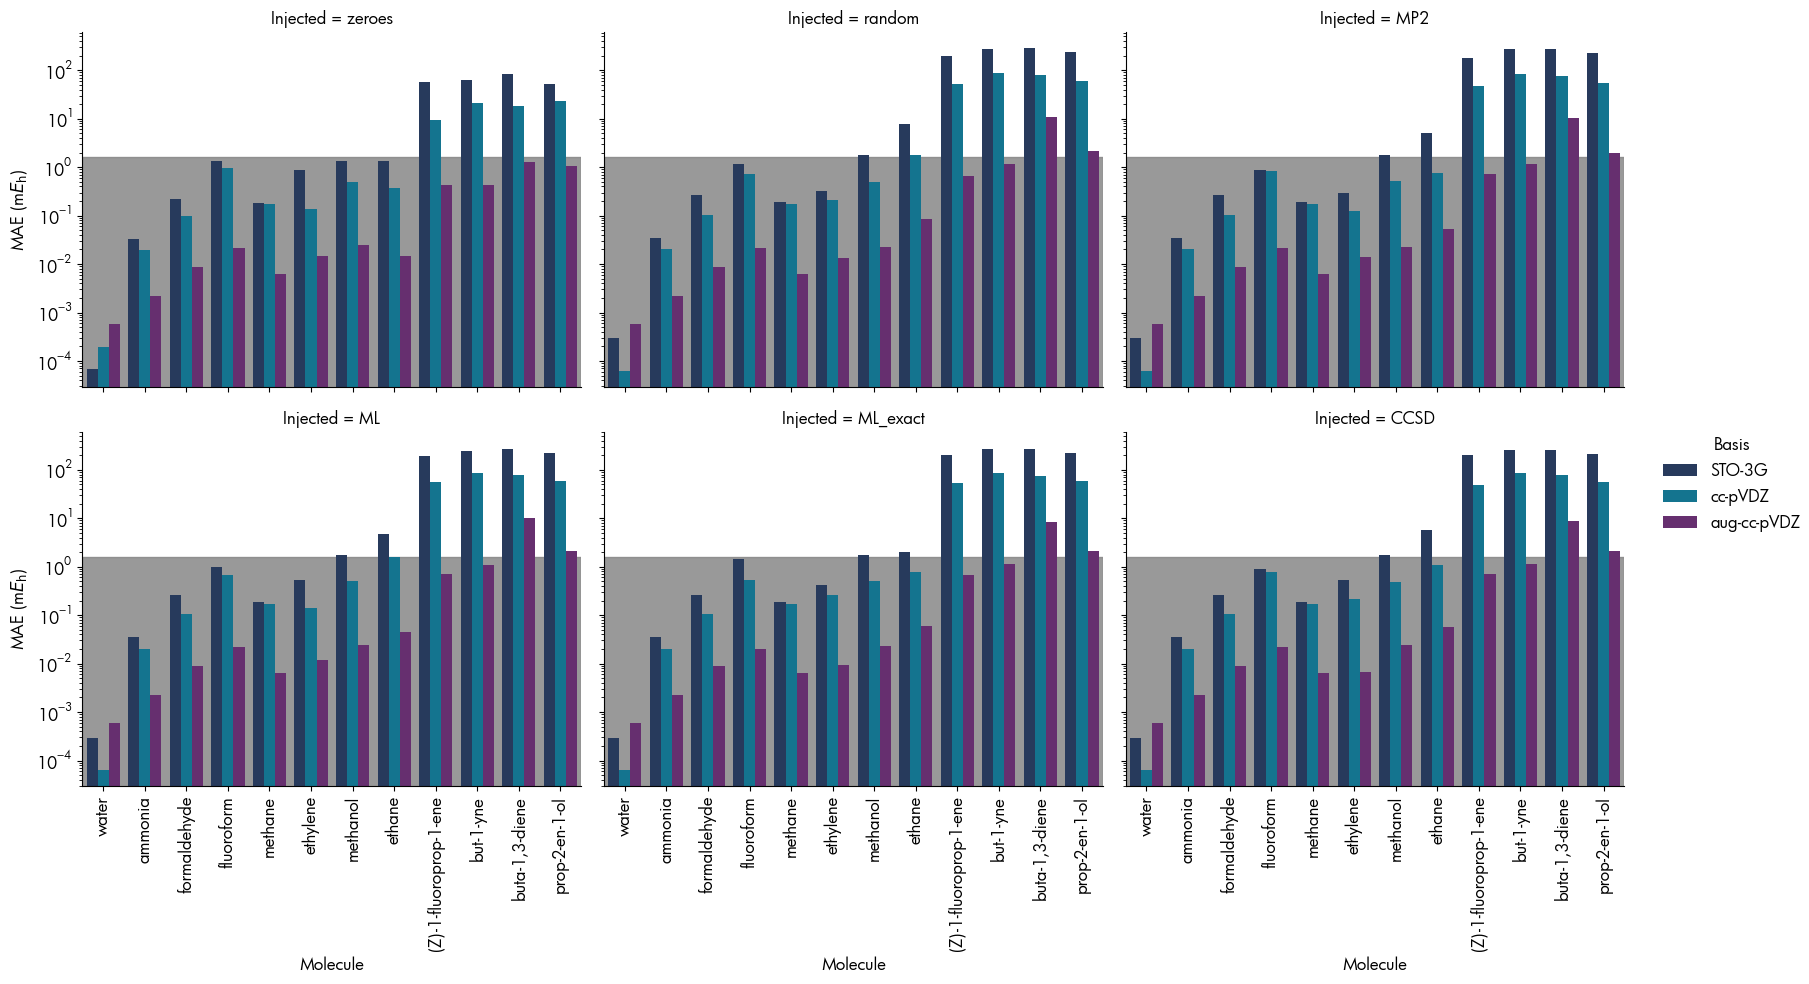

In [56]:
g = sns.catplot(data=inj_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette,col_wrap=3)
for ax in g.axes.flat:
    ax.set_yscale("log")
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(r"MAE (m$E_{\mathrm{h}}$)")
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)        
# plt.legend(loc='center right', bbox_to_anchor=(1.5, 0.5))        
plt.tight_layout()        
plt.savefig("GMJ_figures/MAE_inj_mol_basis.png",dpi=300,bbox_inches='tight')

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_4679/2938803511.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=mol_mae_df,x='Molecule',y='MAE',hue='Basis',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette)


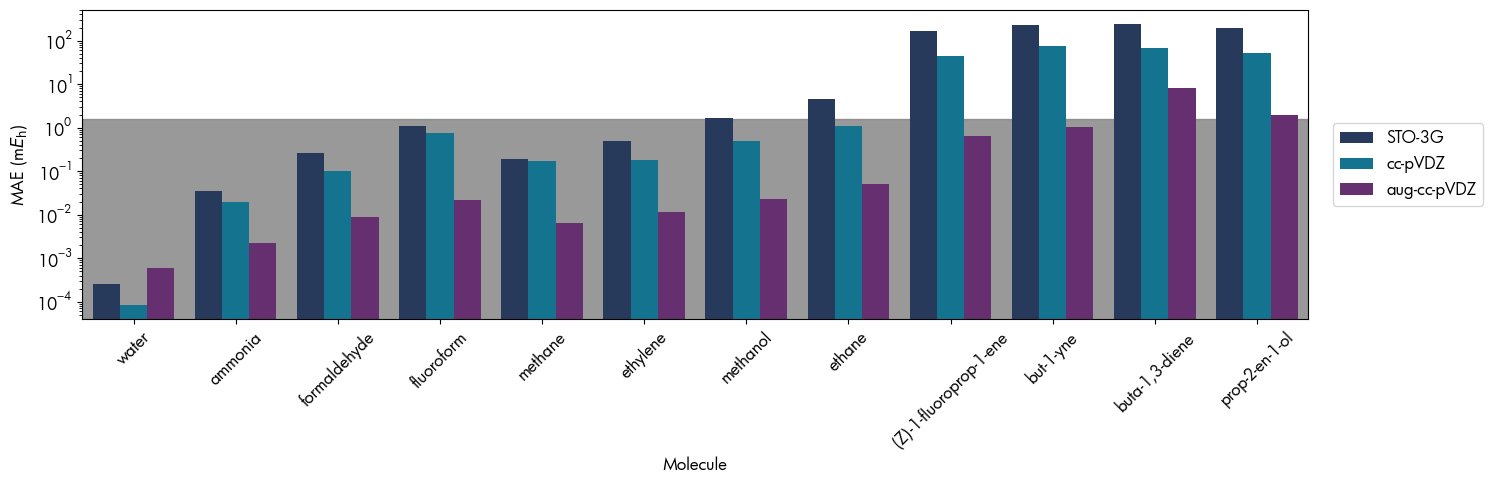

In [57]:
plt.figure(figsize=(15,5))
sns.barplot(data=mol_mae_df,x='Molecule',y='MAE',hue='Basis',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette)
plt.yscale("log")
plt.ylabel(r"MAE (m$E_{\mathrm{h}}$)")
plt.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
plt.xticks(rotation=45)
plt.legend(loc='center right', bbox_to_anchor=(1.15, 0.5))
plt.tight_layout()
plt.savefig("GMJ_figures/MAE_mol_basis.png",dpi=300,bbox_inches='tight')

In [58]:
for basis, inj in product(uniqueBasis,uniqueInj):
    mask = (LUCJDF['Basis Set']==basis)&(LUCJDF['Injected']==inj)
    print(f"{basis} {inj} {mean_absolute_error(LUCJDF.loc[mask,'Energy'],LUCJDF.loc[mask,'Energy (HCI)'])*1e3:.2f} mEh")

STO-3G zeroes 21.87 mEh
STO-3G random 83.81 mEh
STO-3G MP2 79.53 mEh
STO-3G ML 79.16 mEh
STO-3G ML_exact 81.18 mEh
STO-3G CCSD 79.01 mEh
cc-pVDZ zeroes 6.13 mEh
cc-pVDZ random 23.69 mEh
cc-pVDZ MP2 21.84 mEh
cc-pVDZ ML 23.46 mEh
cc-pVDZ ML_exact 22.83 mEh
cc-pVDZ CCSD 22.68 mEh
aug-cc-pVDZ zeroes 0.27 mEh
aug-cc-pVDZ random 1.24 mEh
aug-cc-pVDZ MP2 1.21 mEh
aug-cc-pVDZ ML 1.19 mEh
aug-cc-pVDZ ML_exact 1.05 mEh
aug-cc-pVDZ CCSD 1.09 mEh


In [59]:
for basis in uniqueBasis:
    basismask = (LUCJDF['Basis Set'] == basis)
    # print(basis, f"{1e3*mean_absolute_error(LUCJDF.loc[basismask,'Energy'],LUCJDF.loc[basismask,'Energy (HCI)']):.2f} mEh")
    for inj in uniqueInj:
        injmask = basismask&(LUCJDF['Injected'] == inj)
        print(basis, inj, f"{1e3*mean_absolute_error(LUCJDF.loc[injmask,'Energy'],LUCJDF.loc[injmask,'Energy (HCI)']):.2f} mEh")
        # for layers in sorted(uniqueLayers):
        #     mask = injmask&(LUCJDF['L'] == layers)
        #     print(basis, inj, layers, f"{1e3*mean_absolute_error(LUCJDF.loc[mask,'Energy'],LUCJDF.loc[mask,'Energy (HCI)']):.2f} mEh")

STO-3G zeroes 21.87 mEh
STO-3G random 83.81 mEh
STO-3G MP2 79.53 mEh
STO-3G ML 79.16 mEh
STO-3G ML_exact 81.18 mEh
STO-3G CCSD 79.01 mEh
cc-pVDZ zeroes 6.13 mEh
cc-pVDZ random 23.69 mEh
cc-pVDZ MP2 21.84 mEh
cc-pVDZ ML 23.46 mEh
cc-pVDZ ML_exact 22.83 mEh
cc-pVDZ CCSD 22.68 mEh
aug-cc-pVDZ zeroes 0.27 mEh
aug-cc-pVDZ random 1.24 mEh
aug-cc-pVDZ MP2 1.21 mEh
aug-cc-pVDZ ML 1.19 mEh
aug-cc-pVDZ ML_exact 1.05 mEh
aug-cc-pVDZ CCSD 1.09 mEh


In [60]:
for basis in uniqueBasis:
    basismask = (LUCJDF['Basis Set'] == basis)&(~LUCJDF['Energy (CASCI)'].isna())
    # print(basis, f"{1e3*mean_absolute_error(LUCJDF.loc[basismask,'Energy'],LUCJDF.loc[basismask,'Energy (CASCI)']):.2f} mEh")
    # print(LUCJDF.loc[basismask,'Molecule'].unique())
    for inj in uniqueInj:
        injmask = basismask&(LUCJDF['Injected'] == inj)
        print(basis, inj, f"{1e3*mean_absolute_error(LUCJDF.loc[injmask,'Energy'],LUCJDF.loc[injmask,'Energy (CASCI)']):.2e} mEh")
        # for layers in sorted(uniqueLayers):
        #     mask = injmask&(LUCJDF['L'] == layers)
        #     print(basis, inj, layers, f"{1e3*mean_absolute_error(LUCJDF.loc[mask,'Energy'],LUCJDF.loc[mask,'Energy (CASCI)']):.2f} mEh")

STO-3G zeroes 8.47e-01 mEh
STO-3G random 1.91e+00 mEh
STO-3G MP2 1.41e+00 mEh
STO-3G ML 1.33e+00 mEh
STO-3G ML_exact 9.46e-01 mEh
STO-3G CCSD 1.51e+00 mEh
cc-pVDZ zeroes 8.60e-02 mEh
cc-pVDZ random 4.23e-01 mEh
cc-pVDZ MP2 2.59e-01 mEh
cc-pVDZ ML 3.66e-01 mEh
cc-pVDZ ML_exact 2.57e-01 mEh
cc-pVDZ CCSD 2.85e-01 mEh
aug-cc-pVDZ zeroes 2.17e-03 mEh
aug-cc-pVDZ random 1.70e-02 mEh
aug-cc-pVDZ MP2 1.34e-02 mEh
aug-cc-pVDZ ML 1.08e-02 mEh
aug-cc-pVDZ ML_exact 1.38e-02 mEh
aug-cc-pVDZ CCSD 1.39e-02 mEh


In [61]:
ampdf = pd.read_excel("amplitude_data.xlsx",index_col=0).rename(columns={'molecule':'Molecule','basis':'Basis Set','Amplitude':'Injected'})
ampdf['Injected'] = [i.replace("t2_rand","random") if i=='t2_rand' else i.replace("t2_","") for i in ampdf['Injected']]
uniAmpCol = [i for i in ampdf.columns if i not in LUCJDF.columns]
# uniLUCCol = [i for i in LUCJDF.columns if i not in ampdf.columns]

stackedamp = []
for basis, inj, layer, mol in product(uniqueBasis, uniqueInj, uniqueLayers, uniqueMol):
    ampmask = (ampdf['Molecule']==mol) & (ampdf['Basis Set']==basis) & (ampdf['Injected']==inj)
    lucjdfmask = (LUCJDF['Molecule']==mol) & (LUCJDF['Basis Set']==basis) & (LUCJDF['Injected']==inj) & (LUCJDF['L']==layer)

    tmplucj = LUCJDF.loc[lucjdfmask, :].reset_index(drop=True)
    tmpamp = ampdf.loc[ampmask, uniAmpCol].reset_index(drop=True)
    
    combined = pd.concat([tmplucj, tmpamp], axis=1)
    
    stackedamp.append(combined)
stackedamp = pd.concat(stackedamp).reset_index(drop=True)
stackedamp.fillna(0,inplace=True)

In [62]:
# Save bad ones

bad_df = LUCJDF[((LUCJDF['Energy (HCI)'] - LUCJDF['Energy']).abs()*1e3)>=1.6]


# bad_df.sort_values(by=['Molecule','Basis Set','L',"Injected"]).reset_index(drop=True).to_excel("repostprocess.xlsx")
LUCJDF.sort_values(by=['Molecule','Basis Set','L',"Injected"]).reset_index(drop=True).to_excel("repostprocess.xlsx")

In [63]:
with open("rerun_trash.sh",'w') as f:
    for _, row in LUCJDF.loc[LUCJDF['Energy']<-1e4,['Basis Set','Molecule','L','Injected']].iterrows():
        basis, name, layer, injection = row.to_list()
        filename = f"{name}_LUCJ_L{layer}_{basis}_{injection}.sh"
        if os.path.exists(os.path.join('postprocess',filename)) is False:
            print(filename)
        else:
            f.write(filename+"\n")

# Deviation from CCSD initialized

In [64]:
for basis, layer, mol in product(uniqueBasis,uniqueLayers,uniqueMol):
    mask = ((LUCJDF['Basis Set']==basis) &
            (LUCJDF['L']==layer) &
            (LUCJDF['Molecule']==mol) 
           
           )
    print(mol,basis)
    LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - LUCJDF.loc[mask&(LUCJDF['Injected']=='CCSD'),'Energy'].values)*1e3
    # try:
    #     LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Molecule']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SHCI'),'Energy'].values[0])*1e3
    # except:
    #     mol = moldf.loc[moldf['molecule'] == mol,'mol_filename'].values[0].replace('.xyz','')
    #     LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Molecule']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SHCI'),'Energy'].values[0])*1e3

water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
buta-1,3-diene STO-3G
prop-2-en-1-ol STO-3G
water STO-3G
ammonia STO-3G
formaldehyde STO-3G
fluoroform STO-3G
methane STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(

In [65]:
LUCJDF.loc[LUCJDF['Deviation'].idxmax()]

Basis Set                           STO-3G
Molecule                    prop-2-en-1-ol
Method                    LUCJ(L=1/random)
L                                        1
Injected                            random
Energy                         -189.482689
n_atoms                                 10
Energy (HCI)                   -189.727016
Energy (HF)                    -189.480427
Energy (CASCI)                         NaN
Energy (DMRG-CASCI)            -189.749396
Deviation (LUCJ)                       0.0
Deviation (HF)                    2.261601
Deviation (CASCI)                      NaN
Deviation (HCI)                -244.326963
Deviation (DMRG-CASCI)         -266.706901
Deviation                        131.53918
Name: 269, dtype: object

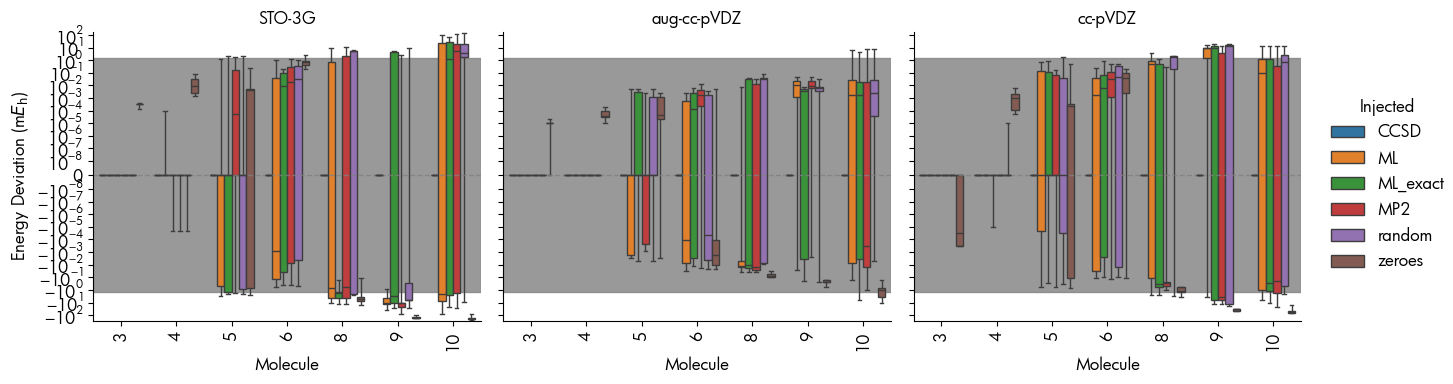

In [66]:
g = sns.catplot(LUCJDF, #[LUCJDF['Injected']!='CCSD'],
                col='Basis Set',
                # col='L',
                x='n_atoms',
                y='Deviation',
                hue='Injected',
                kind='box',
                height=4, 
                # aspect=0.6,
                whis=(0, 100),
                )


# Compute global deviation range for consistent shading/scaling
ymin = LUCJDF["Deviation"].min()
ymax = LUCJDF["Deviation"].max()
pad = 0.2 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-8)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Molecule", r"Energy Deviation (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.tight_layout()        
plt.savefig("GMJ_figures/deviationfromccsd.png",dpi=300,bbox_inches='tight')

In [67]:
uniqueBasis = LUCJDF['Basis Set'].unique()
uniqueMol = LUCJDF['Molecule'].unique()
uniqueInj = LUCJDF['Injected'].unique()
uniqueLayers = LUCJDF['L'].unique()


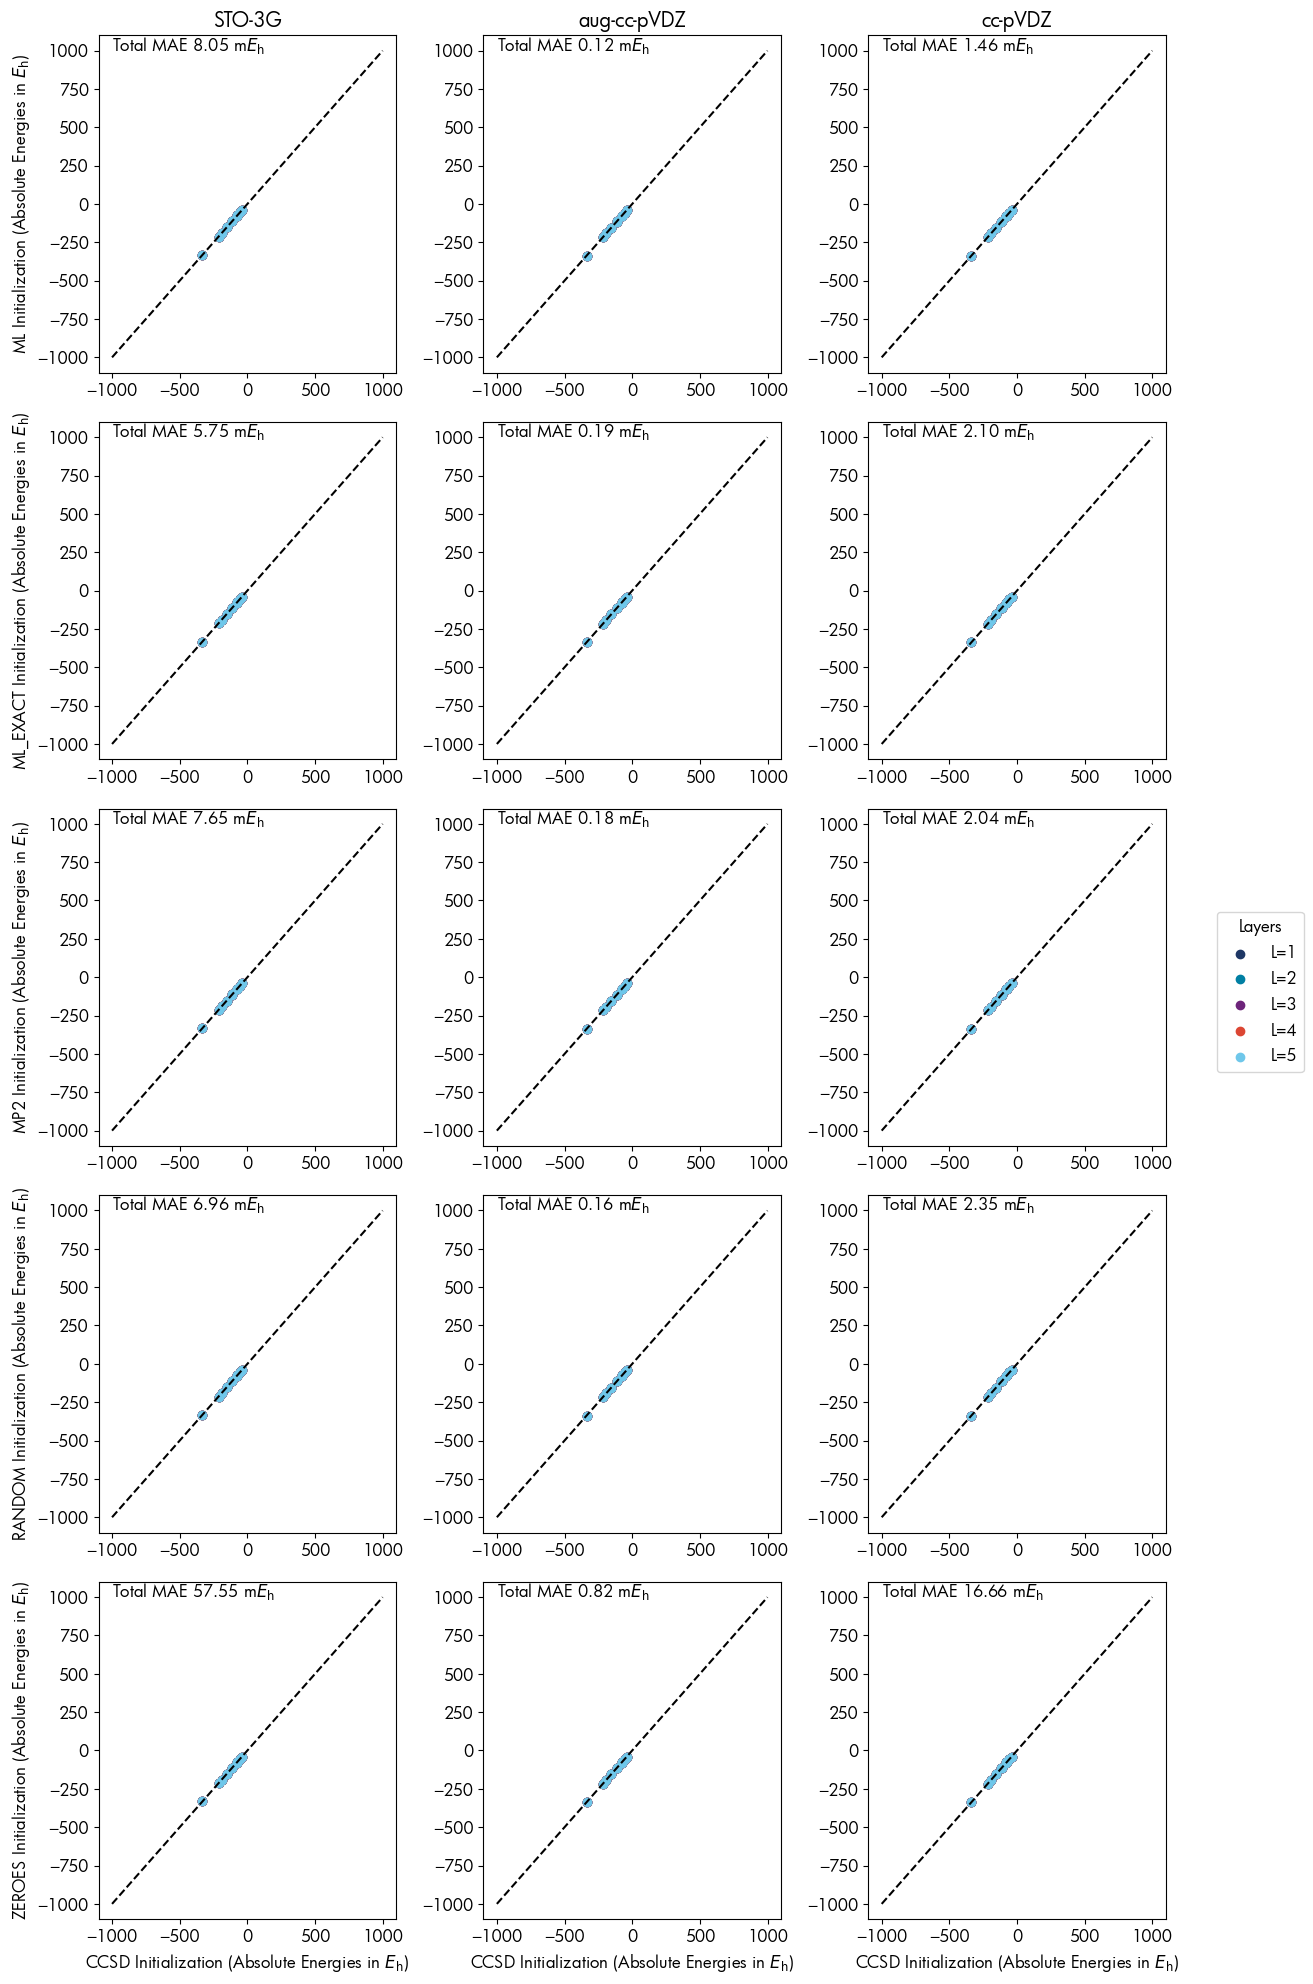

In [68]:
methods = uniqueInj[uniqueInj != 'CCSD']
n_rows = len(methods)
n_cols = len(uniqueBasis)
colors = palette[:len(uniqueLayers)]
layer_color = dict(zip(uniqueLayers, colors))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

stats = []
added_labels = set()  # Fix #2: track labels to avoid duplicates

for (i, method), (j, basis) in product(enumerate(methods), enumerate(uniqueBasis)):
    ax = axes[i, j]
    all_ref, all_vals = [], []  # Fix #1: collect all data for axis limits
    # Loop layers
    for layers in sorted(uniqueLayers):
        ref_list, vals_list = [], []

        for mol in uniqueMol:
            mask = (
                (LUCJDF['Basis Set'] == basis) &
                (LUCJDF['L'] == layers) &
                (LUCJDF['Molecule'] == mol)
            )
            ref = LUCJDF.loc[(LUCJDF['Injected'] == 'CCSD') & mask, 'Energy'].values
            vals = LUCJDF.loc[(LUCJDF['Injected'] == method) & mask, 'Energy'].values

            if len(ref) == 0 or len(vals) == 0 or len(ref) != len(vals):  # Fix #3
                continue

            ref_list.extend(ref)
            vals_list.extend(vals)

        if not ref_list:
            continue

        ref_arr = np.array(ref_list)
        vals_arr = np.array(vals_list)
        all_ref.extend(ref_arr)
        all_vals.extend(vals_arr)

        label = f'L={layers}'
        ax.scatter(
            ref_arr, vals_arr,
            color=layer_color[layers],
            label=label if label not in added_labels else None,  # Fix #2
        )
        added_labels.add(label)
        stats.append((method, basis,layers, mean_absolute_error(ref_arr, vals_arr)*1e3))
    ax.text(-1000,1000,f"Total MAE {mean_absolute_error(all_vals,all_ref)*1e3:.2f}"+r" m$E_{\mathrm{h}}$")
    ax.plot(range(-1000, 1000), range(-1000, 1000), 'k--')

    # if all_ref:  # Fix #1: use aggregated data for limits
    #     ax.set_xlim(np.floor(min(all_ref)), np.ceil(max(all_ref)))
    #     ax.set_ylim(np.floor(min(all_ref)), np.ceil(max(all_ref)))

    if i == 0: ax.set_title(basis)
    if j == 0: ax.set_ylabel(method.upper()+r" Initialization (Absolute Energies in $E_{\mathrm{h}}$)")
    if i == n_rows - 1: ax.set_xlabel(r'CCSD Initialization (Absolute Energies in $E_{\mathrm{h}}$)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Layers', loc='center right', bbox_to_anchor=(1.1, 0.5))
plt.tight_layout() 
plt.savefig("GMJ_figures/parity_plots.png",dpi=300,bbox_inches='tight')

/var/folders/px/qyhp9b8j4bb0z5wgydzgkpxw0000gn/T/ipykernel_4679/249686750.py:1: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(pd.DataFrame(stats,columns=['Method','Basis Set','Layers','MAE']),x='Method',y='MAE',hue='Layers',col='Basis Set',kind='bar',palette=palette)


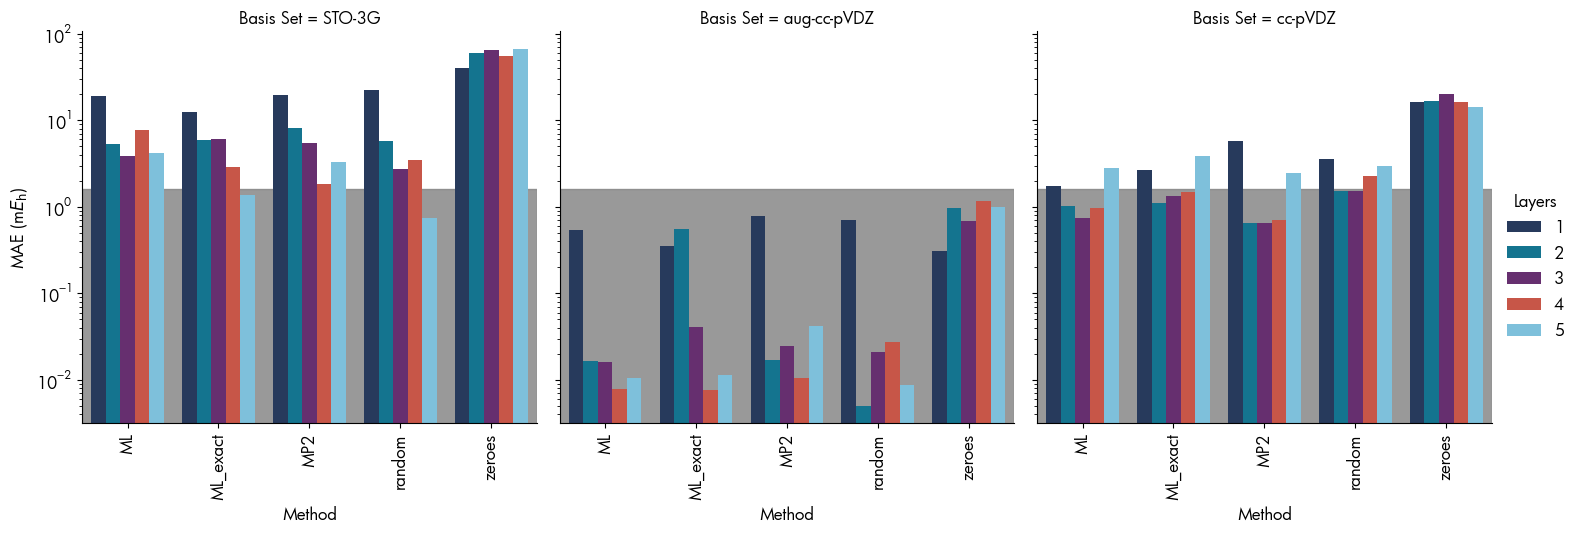

In [69]:
g = sns.catplot(pd.DataFrame(stats,columns=['Method','Basis Set','Layers','MAE']),x='Method',y='MAE',hue='Layers',col='Basis Set',kind='bar',palette=palette)
# g = sns.catplot(data=inj_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette,col_wrap=3)
for ax in g.axes.flat:
    ax.set_yscale("log")
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(r"MAE (m$E_{\mathrm{h}}$)")
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

In [70]:
stats

[('ML', 'STO-3G', np.int64(1), 19.220360833334855),
 ('ML', 'STO-3G', np.int64(2), 5.291336666668182),
 ('ML', 'STO-3G', np.int64(3), 3.841169166665992),
 ('ML', 'STO-3G', np.int64(4), 7.690303333334943),
 ('ML', 'STO-3G', np.int64(5), 4.200209999996929),
 ('ML', 'aug-cc-pVDZ', np.int64(1), 0.5364866666669835),
 ('ML', 'aug-cc-pVDZ', np.int64(2), 0.016560833334011704),
 ('ML', 'aug-cc-pVDZ', np.int64(3), 0.016012500001494345),
 ('ML', 'aug-cc-pVDZ', np.int64(4), 0.007825833337212392),
 ('ML', 'aug-cc-pVDZ', np.int64(5), 0.01048083333661983),
 ('ML', 'cc-pVDZ', np.int64(1), 1.7424516666674588),
 ('ML', 'cc-pVDZ', np.int64(2), 1.031419999999154),
 ('ML', 'cc-pVDZ', np.int64(3), 0.7364400000019108),
 ('ML', 'cc-pVDZ', np.int64(4), 0.9752458333286048),
 ('ML', 'cc-pVDZ', np.int64(5), 2.801821666668758),
 ('ML_exact', 'STO-3G', np.int64(1), 12.511581666665586),
 ('ML_exact', 'STO-3G', np.int64(2), 5.852202500002808),
 ('ML_exact', 'STO-3G', np.int64(3), 6.089067500000785),
 ('ML_exact', 'ST

In [71]:
stat_df = pd.DataFrame(stats,columns=['Method','Basis','Layers','MAE'])
stat_df['Ref'] = 'CCSD'

In [72]:
stat_df

,Method,Basis,Layers,MAE,Ref
0,ML,STO-3G,1,19.220361,CCSD
1,ML,STO-3G,2,5.291337,CCSD
2,ML,STO-3G,3,3.841169,CCSD
3,ML,STO-3G,4,7.690303,CCSD
4,ML,STO-3G,5,4.200210,CCSD
...,...,...,...,...,...
70,zeroes,cc-pVDZ,1,16.100175,CCSD
71,zeroes,cc-pVDZ,2,16.712377,CCSD
72,zeroes,cc-pVDZ,3,19.908992,CCSD
73,zeroes,cc-pVDZ,4,16.290447,CCSD


In [73]:
LUCJDF.loc[LUCJDF.loc[(LUCJDF['Injected'] == 'CCSD') & mask, 'Energy'].index]

,Basis Set,Molecule,Method,L,Injected,Energy,n_atoms,Energy (HCI),Energy (HF),Energy (CASCI),Energy (DMRG-CASCI),Deviation (LUCJ),Deviation (HF),Deviation (CASCI),Deviation (HCI),Deviation (DMRG-CASCI),Deviation
542,cc-pVDZ,"buta-1,3-diene",LUCJ(L=5/CCSD),5,CCSD,-154.93407,10,-155.015451,-154.93392,NaN,-155.019314,0.0,0.149546,NaN,-81.381001,-85.244037,0.0


<Axes: xlabel='Deviation', ylabel='Density'>

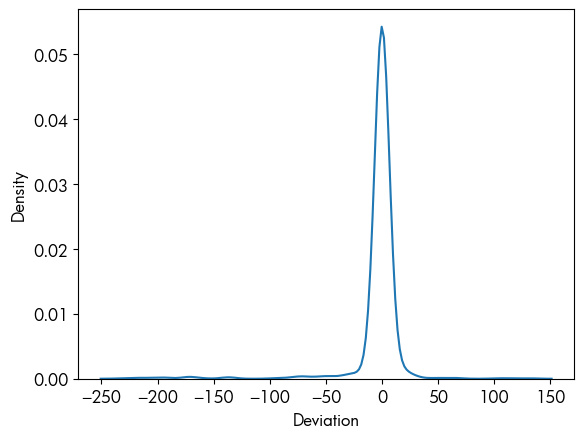

In [74]:
sns.kdeplot(LUCJDF['Deviation'])

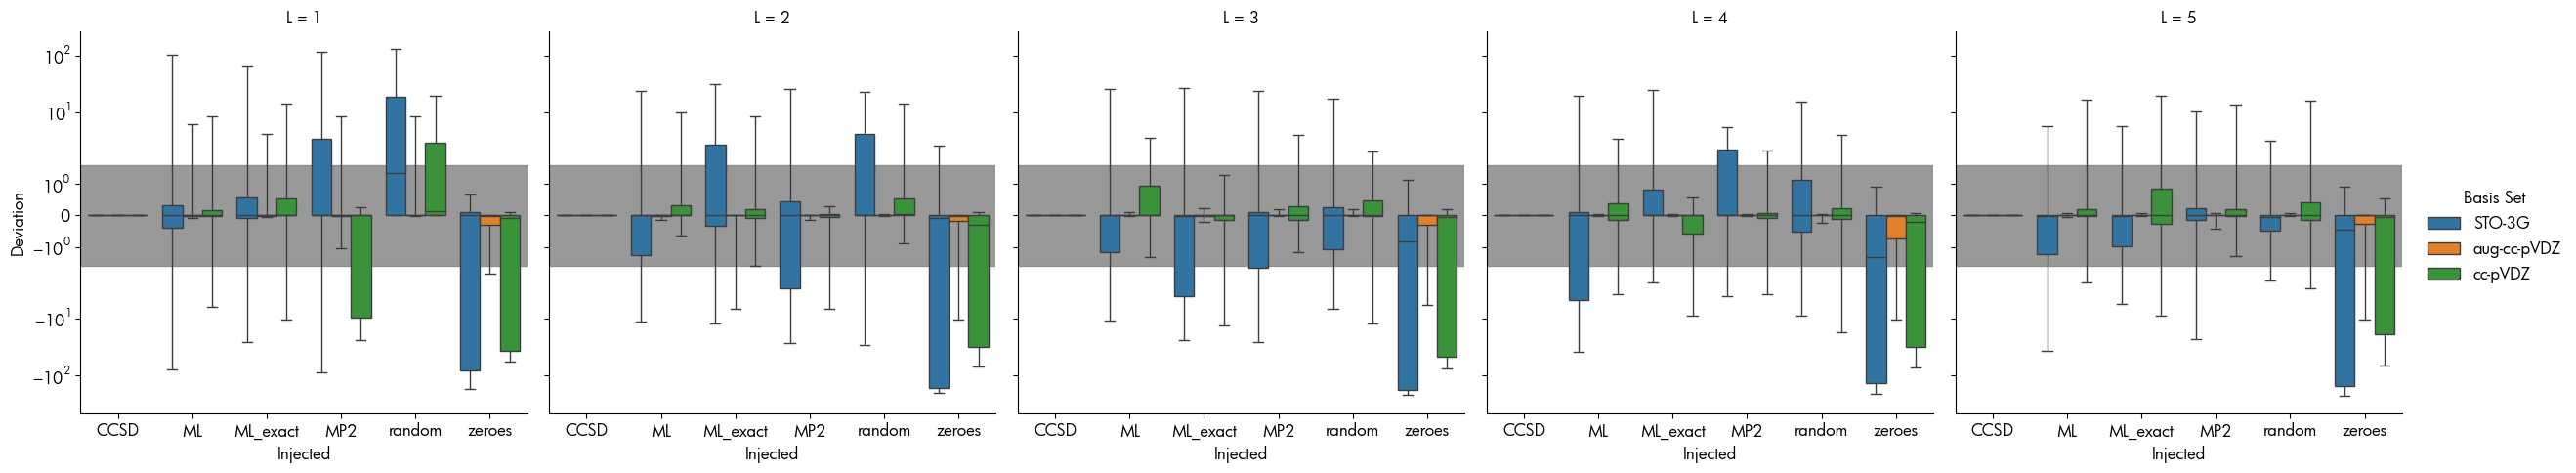

In [75]:
g = sns.catplot(data=LUCJDF, y='Deviation', x='Injected', hue='Basis Set', col='L', kind='box',
                whis=(0, 100))  # or whis=np.inf

for ax in g.axes.flat:
    ax.set_yscale('symlog')
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)

In [76]:
sns.color_palette("colorblind").as_hex()

['#0173b2',
 '#de8f05',
 '#029e73',
 '#d55e00',
 '#cc78bc',
 '#ca9161',
 '#fbafe4',
 '#949494',
 '#ece133',
 '#56b4e9']

In [77]:
for i in sns.color_palette("colorblind").as_hex():
    print(i)

#0173b2
#de8f05
#029e73
#d55e00
#cc78bc
#ca9161
#fbafe4
#949494
#ece133
#56b4e9


In [78]:
LUCJDF['Deviation'].describe()

count    1080.000000
mean       -3.644849
std        26.282190
min      -231.160190
25%        -0.004525
50%         0.000000
75%         0.002380
max       131.539180
Name: Deviation, dtype: float64

# Stack all data

In [79]:
energyDF

,Method,Energy,Molecule,Basis Set
0,HF,-74.960552,water,STO-3G
1,CASCI,-75.009479,water,STO-3G
2,SCI,-75.009478,water,STO-3G
0,HF,-55.454318,ammonia,STO-3G
1,CASCI,-55.519929,ammonia,STO-3G
...,...,...,...,...
31,DMRG-CASCI,-192.001410,prop-2-en-1-ol,cc-pVDZ
32,DMRG-CASCI,-189.749396,prop-2-en-1-ol,STO-3G
33,DMRG-CASCI,-215.950558,(Z)-1-fluoroprop-1-ene,aug-cc-pVDZ
34,DMRG-CASCI,-216.001106,(Z)-1-fluoroprop-1-ene,cc-pVDZ


In [80]:
for a,b in moldf[['molecule','mol_filename']].values:
    if 'GDB' in b:
        name = b.replace('.xyz','')
        energyDF['Name'] = energyDF['Name'].replace(name,a)

KeyError: 'Name'

In [ ]:
energyDF['L'] = len(energyDF)*[np.nan]
energyDF['Injected'] = len(energyDF)*[np.nan]

In [ ]:
energyDF

In [ ]:
upDF = pd.concat([energyDF,LUCJDF]).reset_index().drop(columns=['index'])
upDF['Deviation'] = np.nan

In [ ]:
moldf